# 4. Data preprocessing and feature engineering

A learning algorithm sees the world as a matrix of numbers $\mathbf{X} \in \mathbb{R}^{n \times d}$.
Real data arrive as something else: tables with strings, dates, missing cells, duplicated
rows, typos in category names, impossible values, and columns whose units differ by five
orders of magnitude. Turning such a table into a matrix a model can learn from —
**preprocessing** — and inventing columns that make the problem easier — **feature
engineering** — is where most of the time in a real project goes, where most avoidable
mistakes are made, and where the largest gains are often found: a well-chosen feature can
beat a more powerful model, as we will demonstrate.

The notebook follows one dataset, the raw customer-churn table (`load_churn(raw=True)`),
from its messy state to a reusable preprocessing pipeline that the rest of the course builds
on (notebooks 7, 9, 10, 12, 17, 18 and 20). Along the way we cover missing data, scaling,
encoding of categorical variables, feature construction, feature selection and class
imbalance — always through scikit-learn's `Pipeline` machinery, because the single most
important rule of preprocessing is that *every data-dependent step is fitted on the training
data only* (notebook 5, section 7.1).

**Prerequisites:** notebooks 1 (NumPy/pandas) and 3 (exploratory data analysis). Notebook 5
(generalisation and evaluation) is strongly recommended: we use its cross-validation
vocabulary throughout and rely on its explanation of data leakage.

## Learning objectives

After working through this notebook you will be able to

- explain the *fit on train, transform everything* contract and implement it with `Pipeline`, `ColumnTransformer` and `set_output(transform="pandas")`;
- audit a raw table for duplicates, inconsistent categories, impossible values and type problems, and write a reproducible cleaning function;
- distinguish MCAR, MAR and MNAR missingness, choose between simple, $k$-NN and iterative imputation, and know when to add missing-value indicators;
- choose a scaler or power transform and say which model families need scaling and which do not;
- encode nominal, ordinal and high-cardinality variables, and explain why naive target encoding leaks and how cross fitting fixes it;
- construct domain, interaction, date and binned features, transform skewed targets, and measure whether a feature helps;
- apply filter, wrapper and embedded feature selection inside a cross-validated pipeline, knowing the caveats of impurity importances;
- handle class imbalance with class weights or resampling, and know when *not* to resample;
- assemble, cross-validate and document a complete preprocessing pipeline for a tabular dataset.

## Setup

In [1]:
import json                  # standard library: writes Python dicts and lists to .json files (used in section 9)
from pathlib import Path     # file-system paths as objects (used in section 9 to create a folder)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns        # statistical plots on top of matplotlib (the correlation heatmap in section 7.4)

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_churn() loads the customer-churn table, plot_decision_boundary() draws a 2-D classifier's decision regions
from course_utils import set_style, PALETTE, load_churn, plot_decision_boundary

RANDOM_STATE = 42                          # one fixed seed so every run gives the same splits and random numbers
rng = np.random.default_rng(RANDOM_STATE)  # a seeded NumPy random-number generator
set_style()                                # apply the course-wide matplotlib settings once

## 1. The preprocessing contract

### 1.1 Fit on train, transform everything

Every preprocessing step has the same structure as a model: it **learns something from
data** (the mean and standard deviation of a column, the median used to fill gaps, the list
of categories, a per-category target mean …) and then **applies** it. scikit-learn calls the
two phases `fit` and `transform`, and the contract that keeps evaluation honest is:

> **Key idea.** Statistics are estimated on the *training* data only (`fit`) and then
> applied unchanged to training, validation and test data (`transform`). The test set stands
> in for the future data the model will meet in production — and the future is not available
> when we fit.

Violating the contract is the most common form of **data leakage** (notebook 5, section
7.1): a scaler fitted on all rows "knows" the spread of the test set, an imputer fitted on
all rows fills test gaps with values computed from other test rows, a feature selector that
has seen the test labels picks features that look good on the test set. The damage ranges
from a slightly optimistic score to a fictitious result, and it is invisible until the model
meets genuinely new data.

One consequence surprises beginners: after standardisation the training columns have mean
exactly 0 and standard deviation exactly 1, but the *test* columns do not, because they were
transformed with the training statistics. That is correct behaviour.

In [2]:
from sklearn.model_selection import train_test_split    # splits the rows at random into a training and a test part
from sklearn.preprocessing import StandardScaler        # rescales each column to mean 0 and standard deviation 1

churn = load_churn()                       # the cleaned data (we rebuild the cleaning in section 2)
# double brackets select a two-column DataFrame; .dropna() drops the rows with a missing value in either column
X_demo = churn[["tenure_months", "monthly_charges"]].dropna()
# test_size=0.25 sends a random 25 % of the rows to X_te; random_state makes the shuffle reproducible
X_tr, X_te = train_test_split(X_demo, test_size=0.25, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_tr)        # learns mean_ and scale_ from the TRAINING rows only
# .transform computes (x - mean_) / scale_ with the learned values and returns NumPy arrays
Z_tr, Z_te = scaler.transform(X_tr), scaler.transform(X_te)
# one learned value per column; scale_ is the standard deviation of the training column
print("learned means:", scaler.mean_.round(2), "  learned scales:", scaler.scale_.round(2))
# .mean(0) is .mean(axis=0): one value per column
print(f"train after scaling: mean = {Z_tr.mean(0).round(3)}, std = {Z_tr.std(0).round(3)}")
print(f"test  after scaling: mean = {Z_te.mean(0).round(3)}, std = {Z_te.std(0).round(3)}   <- not exactly 0/1, and that is correct")

learned means: [28.63 68.93]   learned scales: [20.53 27.77]
train after scaling: mean = [0. 0.], std = [1. 1.]
test  after scaling: mean = [ 0.003 -0.001], std = [1.019 0.961]   <- not exactly 0/1, and that is correct


Seen as a picture, the contract is simply a change of units that is *decided by the training
cloud and then imposed on everything else*. The two clouds move and shrink together; the
training cloud lands exactly on the origin with unit spread, and the test cloud lands
wherever the training statistics put it.

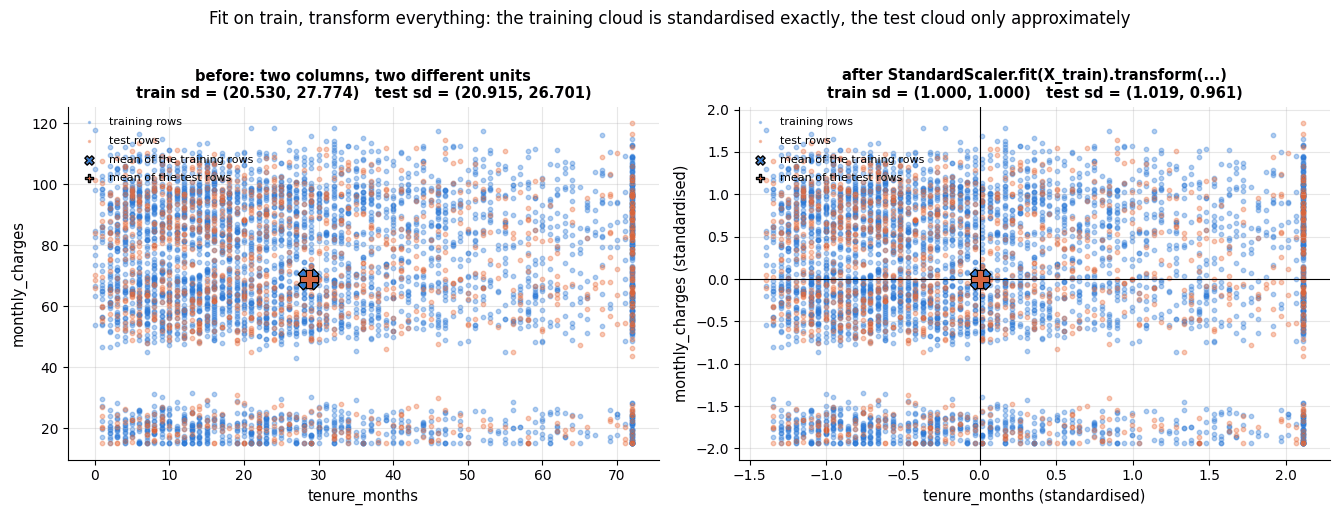

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))
# one (training array, test array, title) triple per panel: raw values on the left, scaled values on the right
for ax, (Xtr_v, Xte_v, title) in zip(axes, [
        (X_tr.to_numpy(), X_te.to_numpy(), "before: two columns, two different units"),
        (Z_tr, Z_te, "after StandardScaler.fit(X_train).transform(...)")]):
    # Xtr_v.T has shape (2, n); the * unpacks its two rows into the x and y arguments of scatter
    ax.scatter(*Xtr_v.T, s=10, alpha=0.35, color=PALETTE[0], label="training rows")
    ax.scatter(*Xte_v.T, s=10, alpha=0.35, color=PALETTE[1], label="test rows")
    # the two column means drawn as one large marker; zorder=5 puts it on top of the dots
    ax.scatter(*Xtr_v.mean(0), s=220, marker="X", color=PALETTE[0], edgecolor="black", lw=1, zorder=5,
               label="mean of the training rows")
    ax.scatter(*Xte_v.mean(0), s=170, marker="P", color=PALETTE[1], edgecolor="black", lw=1, zorder=5,
               label="mean of the test rows")
    ax.set_xlabel("tenure_months")
    ax.set_ylabel("monthly_charges")
    # the numbers go in the title, where they cannot collide with the legend markers
    ax.set_title(f"{title}\ntrain sd = ({Xtr_v.std(0)[0]:.3f}, {Xtr_v.std(0)[1]:.3f})   "
                 f"test sd = ({Xte_v.std(0)[0]:.3f}, {Xte_v.std(0)[1]:.3f})", fontsize=10.5)
    ax.legend(loc="upper left", fontsize=8, markerscale=0.45, labelspacing=0.8)   # markerscale: smaller legend markers
axes[1].axhline(0, color="black", lw=0.8)      # cross-hairs through the origin of the standardised panel
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("tenure_months (standardised)")
axes[1].set_ylabel("monthly_charges (standardised)")
fig.suptitle("Fit on train, transform everything: the training cloud is standardised exactly, "
             "the test cloud only approximately", y=1.02)
plt.tight_layout()
plt.show()

### 1.2 Pipelines and column transformers

Doing this by hand for a dozen steps and two dozen columns is error-prone. Three tools make
the contract automatic:

- **`Pipeline`** chains transformers and a final estimator into one object. `pipe.fit(X, y)`
  fits each step on the output of the previous one; `pipe.predict(X_new)` transforms and
  predicts. Inside `cross_val_score` or `GridSearchCV` the whole chain is refitted on every
  training fold, so nothing leaks.
- **`ColumnTransformer`** applies *different* transformers to *different columns* and
  concatenates the results; `make_column_selector` picks columns by dtype or name pattern.
- **`set_output(transform="pandas")`** makes transformers return DataFrames with meaningful
  column names instead of anonymous arrays — invaluable for inspecting what a pipeline did.

In [4]:
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder     # turns each category into its own 0/1 column
from sklearn.impute import SimpleImputer            # fills missing values with one statistic per column

X_small = churn[["tenure_months", "monthly_charges", "total_charges", "contract", "internet_service"]]
# ColumnTransformer([(name, transformer, columns), ...]) applies each transformer to its own columns and puts the
# results side by side. verbose_feature_names_out=False keeps plain column names (no "num__" / "cat__" prefix);
# .set_output(transform="pandas") makes .transform() return a DataFrame instead of a NumPy array
preprocess_demo = ColumnTransformer([
    # a Pipeline is a list of (name, step) pairs run in order: fill gaps with the column median, then standardise
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
     make_column_selector(dtype_include="number")),     # selects every numeric column when fitted
    # handle_unknown="ignore": a category not seen in fit becomes all zeros; sparse_output=False: a dense array
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     make_column_selector(dtype_exclude="number")),     # every non-numeric (here: text) column
], verbose_feature_names_out=False).set_output(transform="pandas")

preprocess_demo.fit(X_small.iloc[:4000])                # "training" rows (the first 4000, by position)
preprocess_demo.transform(X_small.iloc[4000:]).head()   # "new" rows, transformed with training statistics

,tenure_months,monthly_charges,total_charges,contract_Month-to-month,contract_One year,contract_Two year,internet_service_DSL,internet_service_Fiber optic,internet_service_No
4000,-1.343320,-1.786683,-1.139897,0.0,1.0,0.0,0.0,0.0,1.0
4001,0.009810,-0.715600,-0.321550,1.0,0.0,0.0,1.0,0.0,0.0
4002,1.169636,0.929368,1.729556,0.0,0.0,1.0,0.0,1.0,0.0
4003,-0.425125,-0.259472,-0.461966,1.0,0.0,0.0,1.0,0.0,0.0
4004,0.686375,0.279159,0.743707,1.0,0.0,0.0,1.0,0.0,0.0


The object you just built has a shape, and it is worth drawing once and keeping in mind for
the rest of the notebook: a `ColumnTransformer` is a *fan-out* over column groups, each group
travelling down its own `Pipeline`, with the results concatenated into a single matrix that
the model finally sees. Everything inside the dashed box is refitted from scratch on every
training fold — which is precisely why nothing leaks.

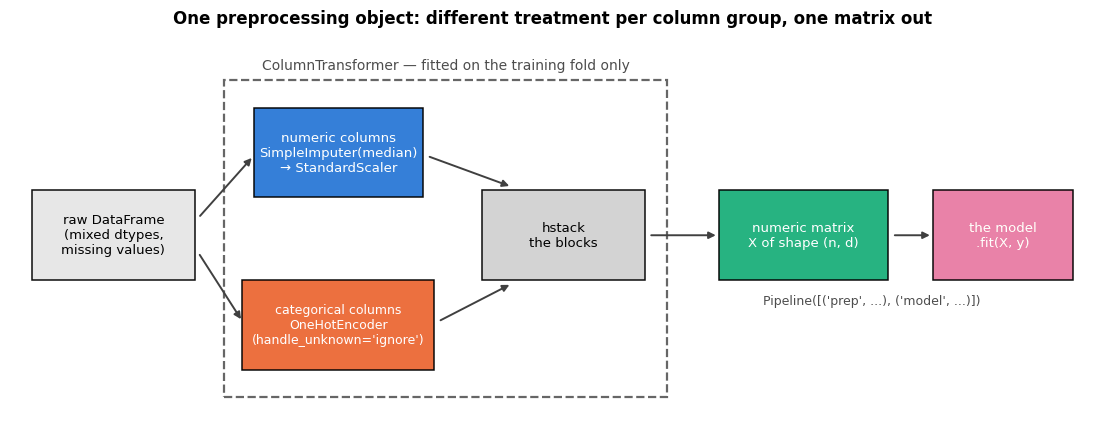

In [5]:
def flow_box(ax, x, y, w, h, text, colour, fontsize=9.5, text_colour="black"):
    """A labelled box for the flow diagram.

    Draws a filled rectangle on `ax` with lower-left corner (x, y), width w and height h,
    and writes `text` in its centre with the given font size and text colour.
    """
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=colour, edgecolor="black", lw=1.1, alpha=0.95))
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, color=text_colour)

def flow_arrow(ax, x0, y0, x1, y1):
    """Draw an arrow on `ax` from (x0, y0) to (x1, y1)."""
    # annotate with empty text draws only an arrow, from xytext to xy; "-|>" has a filled arrowhead
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0), arrowprops={"arrowstyle": "-|>", "lw": 1.4, "color": "0.25"})

fig, ax = plt.subplots(figsize=(14, 5.2))
# the dashed frame around the ColumnTransformer part (fill=False draws only the outline)
ax.add_patch(plt.Rectangle((2.6, 0.2), 6.0, 4.6, fill=False, edgecolor="0.4", lw=1.6, ls="--"))
ax.text(5.6, 4.95, "ColumnTransformer — fitted on the training fold only", ha="center", fontsize=10, color="0.3")

# one box per stage, placed by hand in data coordinates ("0.9" and "0.82" are light greys)
flow_box(ax, 0.0, 1.9, 2.2, 1.3, "raw DataFrame\n(mixed dtypes,\nmissing values)", "0.9")
flow_box(ax, 3.0, 3.1, 2.3, 1.3, "numeric columns\nSimpleImputer(median)\n→ StandardScaler", PALETTE[0], text_colour="white")
flow_box(ax, 2.85, 0.6, 2.6, 1.3, "categorical columns\nOneHotEncoder\n(handle_unknown='ignore')", PALETTE[1], fontsize=9, text_colour="white")
flow_box(ax, 6.1, 1.9, 2.2, 1.3, "hstack\nthe blocks", "0.82")
flow_box(ax, 9.3, 1.9, 2.3, 1.3, "numeric matrix\nX of shape (n, d)", PALETTE[2], text_colour="white")
flow_box(ax, 12.2, 1.9, 1.9, 1.3, "the model\n.fit(X, y)", PALETTE[4], text_colour="white")

# arrows: raw table -> both branches -> hstack -> matrix -> model
flow_arrow(ax, 2.25, 2.8, 3.0, 3.7)
flow_arrow(ax, 2.25, 2.3, 2.85, 1.3)
flow_arrow(ax, 5.35, 3.7, 6.5, 3.25)
flow_arrow(ax, 5.50, 1.3, 6.5, 1.85)
flow_arrow(ax, 8.35, 2.55, 9.3, 2.55)
flow_arrow(ax, 11.65, 2.55, 12.2, 2.55)
ax.text(9.9, 1.55, "Pipeline([('prep', ...), ('model', ...)])", fontsize=9, color="0.3")

ax.set_xlim(-0.3, 14.4)       # fixed coordinate ranges that fit the hand-placed boxes
ax.set_ylim(-0.3, 5.5)
ax.set_xticks([])
ax.set_yticks([])
ax.grid(False)
for spine in ax.spines.values():        # a diagram needs no axes frame
    spine.set_visible(False)
ax.set_title("One preprocessing object: different treatment per column group, one matrix out")
plt.show()

Every transformer in this notebook is used this way. The remaining sections are about
*which* transformers to put into the pipeline, and why.

## 2. Cleaning the raw churn data

Our running example is a synthetic telco-style dataset of 5 000 customers: contract and
payment details, services, charges, support tickets and a binary target `churned`. The file
ships with realistic defects that we will find and fix.

In [6]:
raw = load_churn(raw=True)     # the file exactly as shipped: duplicates, gaps, spelling variants, impossible values
print(f"{raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head()                     # the first 5 rows

5005 rows x 15 columns


,customer_id,signup_date,region,senior_citizen,has_partner,tenure_months,contract,payment_method,internet_service,tech_support,streaming,monthly_charges,total_charges,support_tickets,churned
0,C00001,2023-01-26,North,0,0,17,One year,Bank transfer,DSL,0,0,52.96,880.42,0,0
1,C00002,2023-12-15,South,0,1,6,Month-to-month,Bank transfer,Fiber optic,1,0,92.90,NaN,1,1
2,C00003,2023-11-02,West,1,1,8,Two year,Electronic check,Fiber optic,0,0,84.57,696.84,2,1
3,C00004,2018-07-28,North,0,0,72,One year,Electronic check,DSL,0,0,56.87,4242.54,0,0
4,C00005,2023-12-15,North,0,1,6,Month-to-month,Electronic check,DSL,0,0,57.42,359.98,0,0


### 2.1 The audit

Before changing anything, look. A compact audit table per column — dtype, distinct values,
missing count — plus `describe()` for the numeric columns reveals most problems in one
screen (notebook 3 discusses each view in depth; here we go straight to the findings).

In [7]:
def audit(df):
    """One row per column: dtype, distinct values, missing values, an example value.

    Takes any DataFrame and returns a summary DataFrame indexed by the column names of `df`.
    """
    # each entry is a Series indexed by column name; pd.DataFrame lines them up on that index
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),                     # the stored type of each column, as text
        "n_unique": df.nunique(),                           # number of distinct non-missing values
        "n_missing": df.isna().sum(),                       # missing cells per column (True counts as 1)
        "pct_missing": (100 * df.isna().mean()).round(1),   # the mean of a True/False column is the share of True
        "example": df.iloc[0],                              # the first row: one example value per column
    })

display(audit(raw))      # display() renders a table even when it is not the last line of the cell
# describe() summarises the numeric and date columns; .T gives one row per column; [[...]] keeps five statistics
# ("50%" is the median)
raw.describe().T[["mean", "std", "min", "50%", "max"]].round(2)

,dtype,n_unique,n_missing,pct_missing,example
customer_id,str,5000,0,0.0,C00001
signup_date,datetime64[us],1723,0,0.0,2023-01-26 00:00:00
region,str,8,0,0.0,North
senior_citizen,int64,2,0,0.0,0
has_partner,int64,2,0,0.0,0
tenure_months,int64,73,0,0.0,17
contract,str,3,0,0.0,One year
payment_method,str,4,0,0.0,Bank transfer
internet_service,str,3,0,0.0,DSL
tech_support,int64,2,0,0.0,0


,mean,std,min,50%,max
signup_date,2022-02-07 02:48:01.438561,NaN,2018-07-03 00:00:00,2022-07-14 00:00:00,2024-06-30 00:00:00
senior_citizen,0.158841,0.365564,0.0,0.0,1.0
has_partner,0.483716,0.499785,0.0,0.0,1.0
tenure_months,28.645954,20.637069,0.0,23.0,72.0
tech_support,0.290709,0.454135,0.0,0.0,1.0
streaming,0.367433,0.482154,0.0,0.0,1.0
monthly_charges,69.474653,35.697261,15.0,71.59,999.0
total_charges,1984.953354,1734.292326,15.54,1422.91,9028.77
support_tickets,1.00979,1.156129,0.0,1.0,8.0
churned,0.326474,0.46897,0.0,0.0,1.0


Four findings, each a different *kind* of problem:

1. **Duplicated rows** — `customer_id` has 5 000 distinct values but there are 5 005 rows.
2. **Missing values** — `total_charges` is missing in 154 rows (3.1 %); no other column has gaps.
3. **Impossible values** — `monthly_charges` has a maximum of 999 while the 75th percentile is
   92; a telco bill does not reach 999, so these look like placeholder codes.
4. **Inconsistent categories** — `region` has 8 distinct values where 4 are expected.

Numbers in a table are easy to skim past; the same four findings drawn side by side are hard
to miss, and the picture is a useful artefact in its own right — paste it into the data-quality
section of a project report and a non-technical reader understands the state of the data in
five seconds.

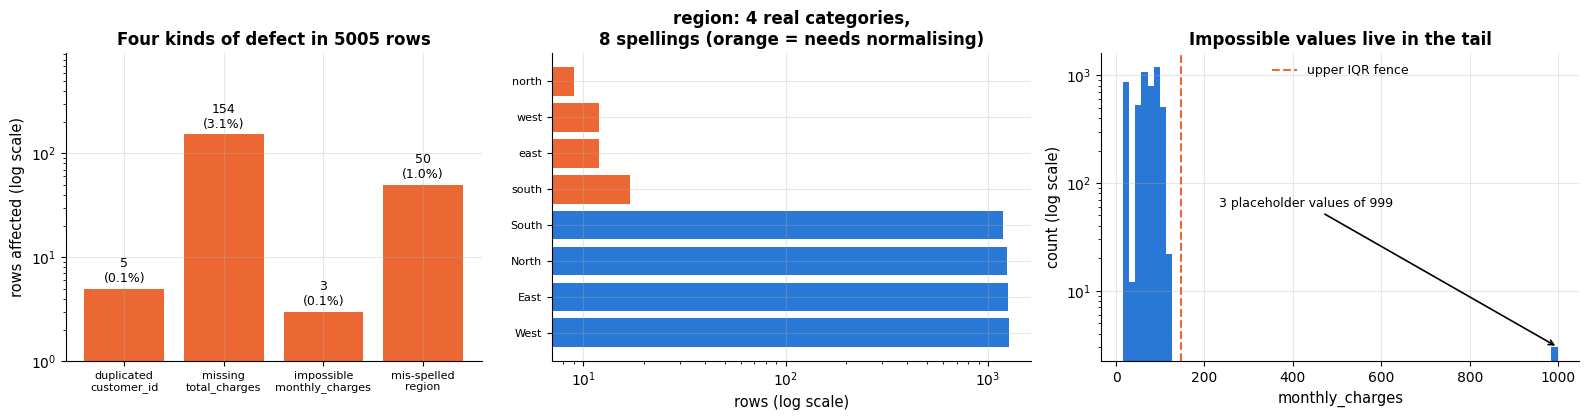

In [8]:
# count each kind of defect; int(...) turns the NumPy integer returned by .sum() into a plain Python int
defects = {
    "duplicated\ncustomer_id": int(raw["customer_id"].duplicated().sum()),     # ids that repeat an earlier row's id
    "missing\ntotal_charges": int(raw["total_charges"].isna().sum()),
    "impossible\nmonthly_charges": int((raw["monthly_charges"] > 200).sum()),
    # rows whose spelling changes when normalised (.str.strip() removes spaces, .str.title() fixes the case)
    "mis-spelled\nregion": int((raw["region"] != raw["region"].str.strip().str.title()).sum()),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3), gridspec_kw={"width_ratios": [1, 1.15, 1.15]})
bars = axes[0].bar(list(defects), list(defects.values()), color=PALETTE[1])   # list(dict) gives the keys
for b, v in zip(bars, defects.values()):
    # b.get_x() + b.get_width() / 2 is the centre of bar b; :.1% formats a fraction as a percentage
    axes[0].text(b.get_x() + b.get_width() / 2, v * 1.15, f"{v}\n({v / len(raw):.1%})", ha="center", fontsize=9)
axes[0].set_yscale("log")
axes[0].set_ylim(1, max(defects.values()) * 6)
axes[0].set_ylabel("rows affected (log scale)")
axes[0].set_title(f"Four kinds of defect in {len(raw)} rows")
axes[0].tick_params(axis="x", labelsize=8)

counts = raw["region"].value_counts()          # rows per distinct spelling, most frequent first
# True for the spellings that are already canonical (no surrounding spaces, title case)
canonical = counts.index.to_series().apply(lambda s: s == s.strip().title())
axes[1].barh(counts.index, counts.values,
             color=[PALETTE[0] if ok else PALETTE[1] for ok in canonical])    # blue if canonical, orange if not
axes[1].set_xscale("log")
axes[1].set_xlabel("rows (log scale)")
axes[1].set_title("region: 4 real categories,\n8 spellings (orange = needs normalising)")
axes[1].tick_params(axis="y", labelsize=8)

# .quantile([0.25, 0.75]) returns two values, unpacked into the first and third quartile
q1, q3 = raw["monthly_charges"].quantile([0.25, 0.75])
axes[2].hist(raw["monthly_charges"], bins=70, color=PALETTE[0])
# Tukey's upper fence Q3 + 1.5 * IQR, where IQR = Q3 - Q1 (the outlier rule of notebook 3)
axes[2].axvline(q3 + 1.5 * (q3 - q1), color=PALETTE[1], ls="--", lw=1.5, label="upper IQR fence")
axes[2].set_yscale("log")
# a text label with an arrow pointing at the placeholder values (xy = arrow tip, xytext = text position)
axes[2].annotate(f"{(raw['monthly_charges'] > 200).sum()} placeholder values of "
                 f"{raw['monthly_charges'].max():.0f}",
                 xy=(raw["monthly_charges"].max(), (raw["monthly_charges"] > 200).sum()),
                 xytext=(430, 60), ha="center", fontsize=9, arrowprops={"arrowstyle": "->", "lw": 1.2})
axes[2].set_xlabel("monthly_charges")
axes[2].set_ylabel("count (log scale)")
axes[2].set_title("Impossible values live in the tail")
axes[2].legend(loc="upper center", fontsize=9)
plt.tight_layout()
plt.show()

### 2.2 Duplicates

Exact duplicates are easy to find with `duplicated()`; the important question is *which
columns define identity*. Here a customer should appear once, so we deduplicate on
`customer_id`. In other datasets a row is a transaction and repeated identifiers are
legitimate — decide from the meaning of the data, not from the mechanics.

In [9]:
# .duplicated() flags rows identical to an earlier row; on one column it flags repeated values of that column
print(f"exact duplicate rows: {raw.duplicated().sum()};  duplicated customer_id: {raw['customer_id'].duplicated().sum()}")
# keep=False flags every copy, including the first, so both rows of each pair are shown
raw[raw.duplicated(keep=False)].sort_values("customer_id").head(4)

exact duplicate rows: 5;  duplicated customer_id: 5


,customer_id,signup_date,region,senior_citizen,has_partner,tenure_months,contract,payment_method,internet_service,tech_support,streaming,monthly_charges,total_charges,support_tickets,churned
705,C00706,2018-07-12,West,0,0,72,One year,Bank transfer,Fiber optic,0,1,97.44,7082.22,2,1
5004,C00706,2018-07-12,West,0,0,72,One year,Bank transfer,Fiber optic,0,1,97.44,7082.22,2,1
1055,C01056,2021-06-08,West,0,0,37,One year,Bank transfer,DSL,1,0,71.37,2543.43,1,0
5003,C01056,2021-06-08,West,0,0,37,One year,Bank transfer,DSL,1,0,71.37,2543.43,1,0


The five duplicates are exact copies (a typical symptom of an export run twice);
`drop_duplicates(subset="customer_id")` keeps the first occurrence.

> **Warning.** Duplicates are a leakage hazard as well as a data-quality problem: if a copy
> of a training row lands in the test set, the model is evaluated on data it has memorised
> (notebook 5, section 7.1). Deduplicate *before* splitting.

### 2.3 Inconsistent categories

Categorical columns collect spelling variants: capitalisation, trailing spaces, synonyms
("Fibre" vs "Fiber optic"), codes mixed with labels. `value_counts()` on every categorical
column is the fastest way to see them.

In [10]:
for col in ["region", "contract", "payment_method", "internet_service"]:
    # value_counts() counts the rows per distinct value; .to_dict() prints the result compactly as {value: count}
    print(f"{col}: {raw[col].value_counts().to_dict()}")

region: {'West': 1267, 'East': 1259, 'North': 1242, 'South': 1187, 'south': 17, 'east': 12, 'west': 12, 'north': 9}
contract: {'Month-to-month': 2795, 'One year': 1225, 'Two year': 985}
payment_method: {'Electronic check': 1694, 'Bank transfer': 1172, 'Credit card': 1144, 'Mailed check': 995}
internet_service: {'Fiber optic': 2115, 'DSL': 2015, 'No': 875}


`region` contains lower-case variants of the four regions (about 1 % of rows). Normalising
the string — strip whitespace, fix the case — repairs it; for synonyms use a mapping
dictionary (`df["col"].replace({"Fibre": "Fiber optic"})`) kept in code, so that it is
applied identically to future data.

### 2.4 Impossible values and outliers

An **impossible value** violates a hard constraint (negative age, a bill of 999 where the
tariff tops out at 130, a date in the future); an **outlier** is merely unusual. Impossible
values are errors: replace them with "missing" so that the imputer of section 3 handles them,
or drop the row if most of it is wrong. Genuine outliers are *data*: keep them unless the
model is known to be sensitive to them, and then prefer a robust transform (section 4) or
**winsorising** (clipping to a percentile) over deleting rows, because deleting rows changes
the population you are modelling. The IQR rule of notebook 3 flags exactly three rows.

In [11]:
q1, q3 = raw["monthly_charges"].quantile([0.25, 0.75])      # first and third quartile
# Tukey's fences: values more than 1.5 IQR below Q1 or above Q3 are flagged
fence_low, fence_high = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
flagged = raw[(raw["monthly_charges"] < fence_low) | (raw["monthly_charges"] > fence_high)]   # | is element-wise "or"
print(f"IQR fences: [{fence_low:.1f}, {fence_high:.1f}]  ->  {len(flagged)} rows flagged")
flagged[["customer_id", "internet_service", "tenure_months", "monthly_charges", "total_charges"]]

IQR fences: [-0.2, 147.0]  ->  3 rows flagged


,customer_id,internet_service,tenure_months,monthly_charges,total_charges
1111,C01112,DSL,2,999.0,143.07
1821,C01822,No,8,999.0,171.87
3616,C03617,Fiber optic,3,999.0,279.44


For these customers `total_charges` is consistent with a normal bill (a Fiber customer pays
about 85–110 a month), so the 999 is an entry error in one cell. We set that cell to `NaN`
and keep the row.

### 2.5 Types, dates and consistency checks

`signup_date` was parsed into a `datetime64` column by the loader
(`pd.read_csv(..., parse_dates=["signup_date"])`); had it arrived as text,
`pd.to_datetime(col, format="%Y-%m-%d", errors="coerce")` would convert it, turning unparsable
strings into `NaT` rather than raising. Binary columns are already `0/1` integers and the
categorical columns are strings, which scikit-learn's encoders accept directly.

Cleaning should end with **consistency checks** that encode domain knowledge. Here
`tenure_months` and `signup_date` describe the same thing (the snapshot date of the file is
2024-06-30), so we can verify that they agree — and that `total_charges` is missing for every
customer with zero tenure: a new customer has not been billed yet, so this is *structural*
missingness, not an error.

In [12]:
snapshot = raw["signup_date"].max()        # the latest signup date, i.e. the day the file was extracted
# date minus date is a time span; .dt.days converts it to whole days, and // 30 (floor division) to whole months
implied_tenure = (snapshot - raw["signup_date"]).dt.days // 30
zero_tenure = raw["tenure_months"] == 0    # True for customers in their first month
# (a == b).mean() is the share of rows where the two agree; .date() drops the time of day
print(f"snapshot date: {snapshot.date()};  tenure_months agrees with signup_date in {(implied_tenure == raw['tenure_months']).mean():.1%} of rows")
# raw.loc[mask, "col"] keeps the rows where the mask is True; ~mask negates it
print(f"customers with tenure 0: {zero_tenure.sum()}, of which total_charges missing: {raw.loc[zero_tenure, 'total_charges'].isna().sum()}")
print(f"total_charges missing among customers with tenure > 0: {raw.loc[~zero_tenure, 'total_charges'].isna().sum()}")

snapshot date: 2024-06-30;  tenure_months agrees with signup_date in 100.0% of rows
customers with tenure 0: 16, of which total_charges missing: 16
total_charges missing among customers with tenure > 0: 138


### 2.6 The cleaning function

All decisions go into one function, so that the same cleaning is applied to every future
export, is version-controlled and can be unit-tested (notebook 18). Note what the function
does *not* do: it does not impute, scale or encode anything. Those steps depend on training
statistics and belong inside the model pipeline; cleaning is the stateless part that precedes
the train/test split.

In [13]:
def clean_churn(df: pd.DataFrame) -> pd.DataFrame:
    """Stateless cleaning of the raw churn export (no statistics are learned here).

    Takes the raw table (load_churn(raw=True)) and returns a cleaned copy: one row per customer,
    normalised region spellings, and impossible monthly_charges replaced by NaN. The input is not modified.
    """
    # subset="customer_id": rows count as duplicates when their id matches (the first one is kept);
    # .copy() makes an independent frame, so the assignments below never touch the caller's df
    df = df.drop_duplicates(subset="customer_id").copy()               # 1. one row per customer
    df["region"] = df["region"].str.strip().str.title()                # 2. normalise category spelling
    df.loc[df["monthly_charges"] > 200, "monthly_charges"] = np.nan    # 3. impossible values -> missing
    return df.reset_index(drop=True)      # renumber the rows 0..n-1 after dropping the duplicates

cleaned = clean_churn(raw)
# raises an AssertionError if the two frames differ in any value, dtype, column or row label
pd.testing.assert_frame_equal(cleaned, load_churn())   # identical to what load_churn() returns
print(f"cleaned: {cleaned.shape[0]} rows; regions = {sorted(cleaned['region'].unique())}; "
      f"monthly_charges max = {cleaned['monthly_charges'].max():.2f}; churn rate = {cleaned['churned'].mean():.1%}")

cleaned: 5000 rows; regions = ['East', 'North', 'South', 'West']; monthly_charges max = 120.16; churn rate = 32.6%


This is exactly what `load_churn()` does internally, which is why every later notebook can
start from the cleaned table.

## 3. Missing data

### 3.1 Why values are missing matters more than how many

Rubin (1976) introduced the classification that still organises the subject. Let $R$ be the
indicator of a value being observed and $\mathbf{X}_\text{obs}$ the observed part of the data.

| Mechanism | Definition | Example in the churn data | Consequence |
|---|---|---|---|
| **MCAR** — missing completely at random | $P(R \mid \mathbf{X}) = P(R)$ | a random 2.5 % of `total_charges` lost in an export | dropping rows loses power but does not bias; any imputation is unbiased |
| **MAR** — missing at random | $P(R \mid \mathbf{X}) = P(R \mid \mathbf{X}_\text{obs})$: depends on *observed* values only | `total_charges` missing whenever `tenure_months = 0` | unbiased imputation is possible, but only if the imputer *uses the other columns* |
| **MNAR** — missing not at random | depends on the missing value itself | high earners refusing to state their income | no imputation recovers the truth; add an indicator, model the mechanism, or collect more data |

The mechanism cannot be tested from the data alone (MAR and MNAR are indistinguishable
without outside knowledge), but exploration helps: compare the other variables between rows
with and without a gap.

In [14]:
has_gap = cleaned["total_charges"].isna()       # True where total_charges is missing
# group the rows by that True/False Series (.rename names the groups' index); .agg(new_name=(column, function))
# computes one summary per group, and a lambda can serve as a custom summary function
cleaned.groupby(has_gap.rename("total_charges_missing")).agg(
    n=("churned", "size"), churn_rate=("churned", "mean"), mean_tenure=("tenure_months", "mean"),
    share_tenure_0=("tenure_months", lambda s: (s == 0).mean())).round(3)     # share of rows with tenure 0

,n,churn_rate,mean_tenure,share_tenure_0
total_charges_missing,,,,
False,4846,0.324,28.741,0.000
True,154,0.390,25.331,0.104


The gap rows have a higher churn rate and a much larger share of zero-tenure customers:
missingness is *informative* here — a good reason to add a **missing indicator** column in
addition to imputing, so that a model can use the fact that the value was absent. The three
panels below are the standard diagnostic for a missing column: *where* are the gaps, *what
explains them*, and *do they carry signal about the target*.

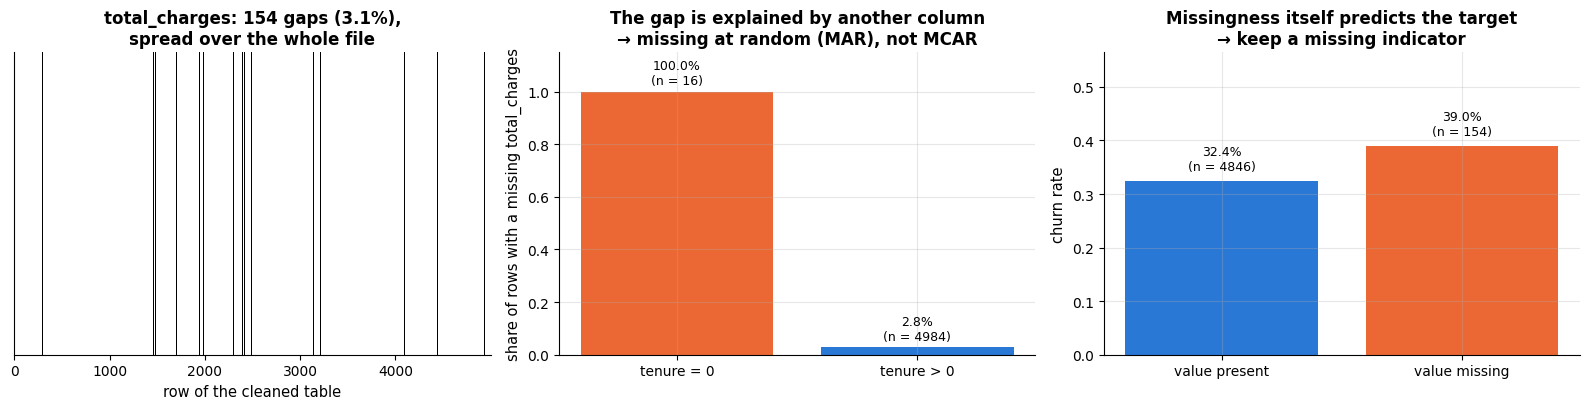

In [15]:
gap = cleaned["total_charges"].isna()
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

# --- left: the gaps as an image one pixel high, one pixel column per row of the table (black = missing);
# .reshape(1, -1) turns shape (n,) into (1, n), where -1 means "infer this length"
axes[0].imshow(gap.to_numpy().reshape(1, -1), aspect="auto", cmap="Greys", vmin=0, vmax=1,
               interpolation="nearest")
axes[0].set_yticks([])
axes[0].set_xlabel("row of the cleaned table")
axes[0].set_title(f"total_charges: {gap.sum()} gaps ({gap.mean():.1%}),\nspread over the whole file")
axes[0].grid(False)

# --- middle: np.where(cond, a, b) gives each row the label a or b
tenure_group = np.where(cleaned["tenure_months"] == 0, "tenure = 0", "tenure > 0")
# group the True/False gap values by those labels: .mean() is the share missing, .size() the group size
# (.to_numpy() discards the index, so values and labels are matched by position)
share = pd.Series(gap.to_numpy()).groupby(tenure_group).mean()
n_group = pd.Series(gap.to_numpy()).groupby(tenure_group).size()
axes[1].bar(share.index, share.values, color=[PALETTE[1], PALETTE[0]])
for i, (s, n) in enumerate(zip(share.values, n_group.values)):
    axes[1].text(i, s + 0.03, f"{s:.1%}\n(n = {n})", ha="center", fontsize=9)    # label above each bar
axes[1].set_ylim(0, 1.15)
axes[1].set_ylabel("share of rows with a missing total_charges")
axes[1].set_title("The gap is explained by another column\n→ missing at random (MAR), not MCAR")

# --- right: churn rate with and without the value; .agg(["mean", "size"]) returns both as columns
rate = cleaned.groupby(gap.rename("missing"))["churned"].agg(["mean", "size"])
axes[2].bar(["value present", "value missing"], rate["mean"], color=[PALETTE[0], PALETTE[1]])
for i, (m, n) in enumerate(zip(rate["mean"], rate["size"])):
    axes[2].text(i, m + 0.02, f"{m:.1%}\n(n = {n})", ha="center", fontsize=9)
axes[2].set_ylim(0, max(rate["mean"]) * 1.45)
axes[2].set_ylabel("churn rate")
axes[2].set_title("Missingness itself predicts the target\n→ keep a missing indicator")
plt.tight_layout()
plt.show()

### 3.2 Imputation strategies

- **`SimpleImputer`** replaces gaps with a constant per column: `mean`, `median` (robust to
  skew — the usual default for numeric features), `most_frequent` (for categoricals) or a
  fixed `constant` such as `"unknown"`. `add_indicator=True` appends a binary column per
  imputed feature.
- **`KNNImputer`** fills a gap with the average of the $k$ most similar rows (Euclidean
  distance on the non-missing columns). It exploits relationships between columns; it needs
  scaled inputs and costs $O(n^2 d)$.
- **`IterativeImputer`** (the chained-equations idea of van Buuren, 2018, in single-imputation
  form) regresses each incomplete column on the others, fills the gaps with predictions and
  cycles through the columns a few times. It is the most accurate choice when columns are
  correlated; it is still marked experimental, hence the `enable_iterative_imputer` import.

Under MCAR all three are unbiased and differ only in variance; under MAR the mean and median
imputers are **biased** because they ignore the columns that explain the missingness. Let
us verify this with a controlled experiment: delete known values of `monthly_charges` under
an MCAR mechanism and under an MAR mechanism (Fiber-optic customers, who pay the most, lose
the value far more often), impute with every method, and measure the error against the
truth. The imputers see the other numeric columns and a one-hot encoding of
`internet_service`, so that they *can* exploit the MAR structure.

MCAR: 1541 values deleted; true mean of deleted values = 70.2, mean of remaining values = 68.4
MAR: 1252 values deleted; true mean of deleted values = 87.8, mean of remaining values = 62.6


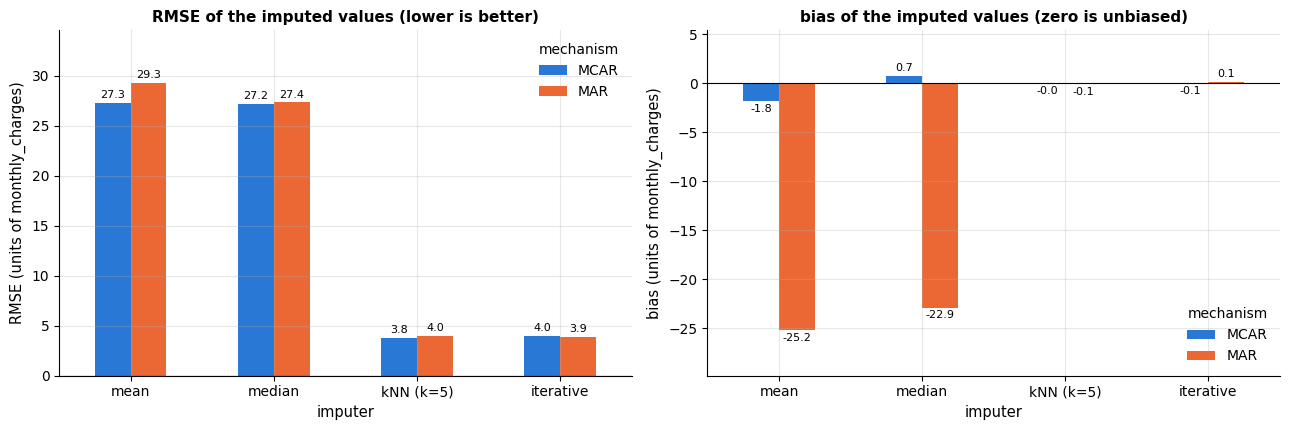

RMSE   bias
mechanism imputer                
MCAR      mean       27.28  -1.83
          median     27.23   0.72
          kNN (k=5)   3.77  -0.04
          iterative   3.98  -0.05
MAR       mean       29.29 -25.20
          median     27.35 -22.92
          kNN (k=5)   4.01  -0.08
          iterative   3.92   0.12

In [16]:
from sklearn.experimental import enable_iterative_imputer  # noqa: F401  (activates IterativeImputer)
# KNNImputer: fills a gap with the average of that column over the k most similar rows;
# IterativeImputer: regresses each column with gaps on the other columns and fills the gaps with the predictions
from sklearn.impute import IterativeImputer, KNNImputer

truth = cleaned["monthly_charges"].to_numpy()       # the real values, as a NumPy array
observed = ~np.isnan(truth)                         # True where the real value is known (only these get deleted)
# the other columns the imputers may use: five numeric columns plus internet_service as 0/1 columns.
# pd.get_dummies one-hot encodes a column (prefix names the new columns "internet_<value>");
# pd.concat(..., axis=1) puts the frames side by side
side_info = pd.concat([
    cleaned[["tenure_months", "total_charges", "support_tickets", "tech_support", "streaming"]],
    pd.get_dummies(cleaned["internet_service"], prefix="internet", dtype=float),
], axis=1)
is_fiber = (cleaned["internet_service"] == "Fiber optic").to_numpy()

imputers = {
    "mean": SimpleImputer(strategy="mean"),
    "median": SimpleImputer(strategy="median"),
    "kNN (k=5)": KNNImputer(n_neighbors=5),     # distances use only the columns both rows have observed
    "iterative": IterativeImputer(max_iter=10, random_state=RANDOM_STATE),   # up to 10 rounds over the columns
}
results = []
imputed_values, deleted_truth = {}, {}          # kept for the figures below
# deletion probability per row. MCAR: 0.3 for every row (np.full makes an array filled with one value);
# MAR: 0.6 for Fiber customers and 0.05 for everyone else
for mechanism, p_missing in [("MCAR", np.full(len(truth), 0.3)), ("MAR", np.where(is_fiber, 0.6, 0.05))]:
    mask = (rng.random(len(truth)) < p_missing) & observed     # one uniform draw per row; True = delete this value
    # .assign adds monthly_charges as a column, with NaN wherever the mask deletes the value
    X_holes = side_info.assign(monthly_charges=np.where(mask, np.nan, truth))
    col = X_holes.columns.get_loc("monthly_charges")             # position of that column in the array output
    deleted_truth[mechanism] = truth[mask]
    for name, imp in imputers.items():
        # kNN needs comparable scales: standardise, impute, undo the scaling
        # (StandardScaler ignores NaN when fitting and keeps it as NaN, so the imputer still sees the gaps)
        pipe = Pipeline([("scale", StandardScaler()), ("impute", imp)])
        # fit_transform fits both steps on X_holes and returns a NumPy array; pipe["scale"] is the fitted scaler,
        # and z * scale_ + mean_ converts standardised values back to the original units
        filled = pipe.fit_transform(X_holes) * pipe["scale"].scale_ + pipe["scale"].mean_
        err = filled[mask, col] - truth[mask]          # imputed minus true value, for the deleted cells only
        imputed_values[(mechanism, name)] = filled[mask, col]
        # RMSE: the typical size of the error; bias: its average (0 means no systematic error)
        results.append({"mechanism": mechanism, "imputer": name, "RMSE": np.sqrt(np.mean(err**2)), "bias": err.mean()})
    # np.nanmean averages while skipping NaN
    print(f"{mechanism}: {mask.sum()} values deleted; true mean of deleted values = {truth[mask].mean():.1f}, "
          f"mean of remaining values = {np.nanmean(X_holes['monthly_charges']):.1f}")
imp_results = pd.DataFrame(results).set_index(["mechanism", "imputer"])    # a two-level row index

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, metric in zip(axes, ["RMSE", "bias"]):
    # .unstack("mechanism") moves that index level into the columns (rows = imputers, columns = MCAR / MAR);
    # .loc[...] fixes the order of the rows and columns
    table = imp_results[metric].unstack("mechanism").loc[list(imputers), ["MCAR", "MAR"]]
    # pandas bar plot: one group of bars per row, one bar per column; rot=0 keeps the labels horizontal
    table.plot.bar(ax=ax, color=[PALETTE[0], PALETTE[1]], rot=0)
    # ax.containers holds one group of bars per series; bar_label writes each bar's height on it
    for container in ax.containers:                      # print the value: the near-zero bars are invisible
        ax.bar_label(container, fmt="%.1f", fontsize=8, padding=2)
    ax.margins(y=0.18)          # extra room above and below the bars for the labels
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"{metric} of the imputed values ({'lower is better' if metric == 'RMSE' else 'zero is unbiased'})",
                 fontsize=11)
    ax.set_xlabel("imputer")
    ax.set_ylabel(f"{metric} (units of monthly_charges)")
    ax.legend(title="mechanism")
plt.tight_layout()
plt.show()
imp_results.round(2)

Under MCAR the mean and median are unbiased but crude (an error of about 27, the standard
deviation of the column), while the $k$-NN and iterative imputers — which exploit the tight
relationship between `monthly_charges`, `total_charges`, `tenure_months` and the service
type — reconstruct the deleted values to within a few units. Under MAR the picture changes
qualitatively for the simple imputers: the deleted values are mostly expensive Fiber bills,
so the mean of the *remaining* values is far too low and mean/median imputation is biased
by more than 20 units, a systematic error that propagates into any downstream model. The
imputers that condition on the other columns remain essentially unbiased. (This dataset is
unusually kind: `total_charges / tenure_months` almost determines the missing value. Real
gains from model-based imputation are smaller, but the bias of mean imputation under MAR is
entirely typical.)

The two summary numbers hide *how* the imputers fail, which the distributions make obvious.
Each panel below compares the true values that were deleted under the MAR mechanism (grey)
with the values each imputer put in their place (coloured). Mean and median imputation
collapse the whole distribution onto a single spike that sits far to the left of the truth —
the bias — while the two conditional imputers reproduce the shape of the deleted values
almost exactly.

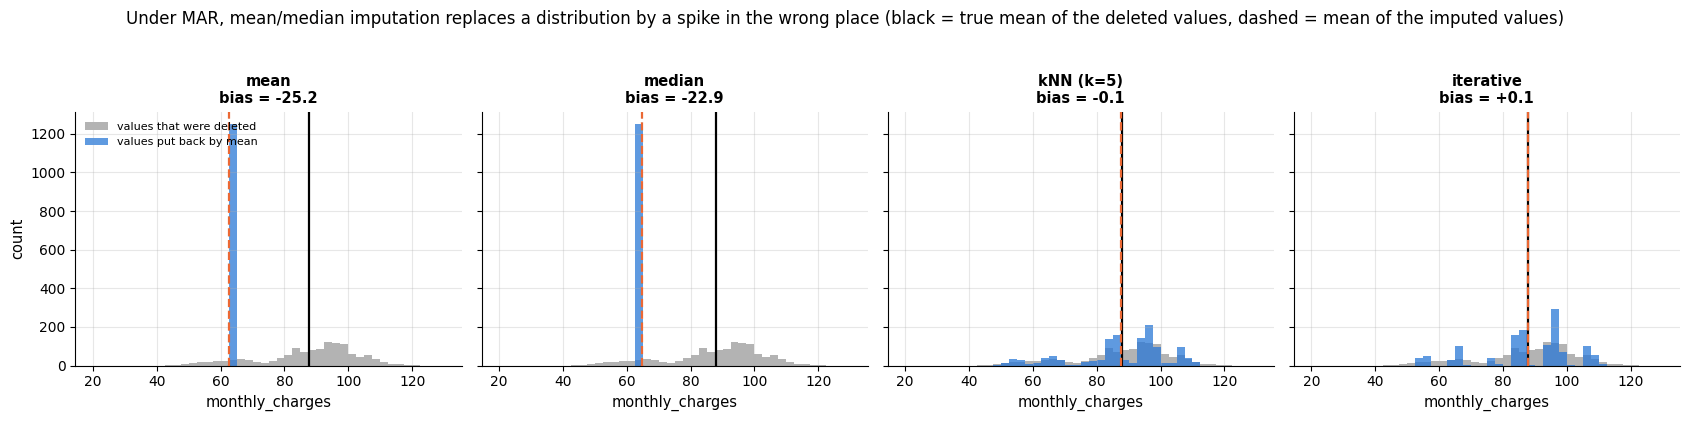

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(17, 4.0), sharex=True, sharey=True)   # all four panels share both axes
bins = np.linspace(20, 130, 45)          # 45 edges -> 44 equal-width bins, identical in every panel
for ax, name in zip(axes, imputers):     # looping over a dict yields its keys (the imputer names)
    true_vals, filled_vals = deleted_truth["MAR"], imputed_values[("MAR", name)]
    # grey: the true values that were deleted; colour (semi-transparent, on top): the values the imputer put back
    ax.hist(true_vals, bins=bins, color="0.7", label="values that were deleted")
    ax.hist(filled_vals, bins=bins, color=PALETTE[0], alpha=0.75, label=f"values put back by {name}")
    ax.axvline(true_vals.mean(), color="black", lw=1.6)
    ax.axvline(filled_vals.mean(), color=PALETTE[1], lw=1.6, ls="--")
    # :+.1f always prints the sign, + or -
    ax.set_title(f"{name}\nbias = {filled_vals.mean() - true_vals.mean():+.1f}", fontsize=10.5)
    ax.set_xlabel("monthly_charges")
axes[0].set_ylabel("count")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Under MAR, mean/median imputation replaces a distribution by a spike in the wrong place "
             "(black = true mean of the deleted values, dashed = mean of the imputed values)", y=1.04)
plt.tight_layout()
plt.show()

### 3.3 Practical rules

- Impute **inside the pipeline**, after the split; fitting an imputer on all rows is leakage.
- Numeric: `median` is a safe default; `IterativeImputer` or `KNNImputer` when columns are
  correlated and the gaps are numerous. Categorical: `most_frequent`, or a dedicated
  `"missing"` category — often the best choice, since it lets the model use the missingness.
- Add **indicators** when missingness may be informative.
- **Drop rows** only when very few are affected and MCAR is plausible; never drop *test*
  rows silently, because production data will have gaps too. **Drop a column** when most
  of it is missing and the indicator alone carries the information.
- `HistGradientBoosting*` handles `NaN` natively (missing values are routed to whichever
  child improves the split), so for trees imputation is optional — but keeping it in the
  pipeline lets you swap models freely.

> **Going deeper.** Single imputation understates uncertainty: filled values are treated as
> if observed. *Multiple imputation* (van Buuren, 2018) draws several plausible completions,
> fits the model on each and pools the results. For prediction the gain is usually small;
> for inference on coefficients it matters. Little & Rubin (2019) is the standard reference.

## 4. Scaling and power transforms

### 4.1 Why scale?

Many algorithms treat the features geometrically or optimise a function whose shape depends
on the units. **Distance-based** methods ($k$-NN, $k$-means, RBF-kernel SVMs) compute
Euclidean distances, in which a feature measured in thousands drowns one measured in units.
**Gradient-based** optimisation (linear and logistic regression by gradient descent, neural
networks) converges slowly on badly scaled problems, because the loss surface is a long
narrow valley (notebook 6, section 2, quantifies this with the condition number).
**Regularised** models (ridge, lasso, logistic regression with its `C`) penalise coefficient
size, and a coefficient's size depends on the feature's unit: the penalty would shrink a
feature in cents ten times harder than the same feature in euros. **PCA** (notebook 14)
maximises variance in whatever units it is given. **Tree-based** models, in contrast, split
on thresholds of one feature at a time and are invariant to monotone transformations; they
do not need scaling, and neither does naive Bayes.

| Transformer | Formula (per column) | Result | Use when |
|---|---|---|---|
| `StandardScaler` | $(x - \bar{x}) / s$ | mean 0, std 1 | default for linear models, SVMs, neural networks |
| `MinMaxScaler` | $(x - x_\min) / (x_\max - x_\min)$ | range $[0, 1]$ | bounded inputs needed (images, some NNs); sensitive to outliers |
| `RobustScaler` | $(x - \text{median}) / \text{IQR}$ | median 0, IQR 1 | heavy tails or outliers |
| `QuantileTransformer` | $F^{-1}_\text{target}(\hat{F}(x))$, rank-based | uniform or normal marginal | strongly skewed data; distorts distances |
| `PowerTransformer` | Box–Cox $\frac{x^\lambda - 1}{\lambda}$ ($x>0$), Yeo–Johnson (any $x$) | approximately Gaussian | skewed positive data before linear models |

Box & Cox (1964) choose the exponent $\lambda$ by maximum likelihood ($\lambda = 0$ means
$\log x$); Yeo & Johnson (2000) extended the family to zero and negative values, which is why
it is scikit-learn's default. `PowerTransformer` standardises the result as well.

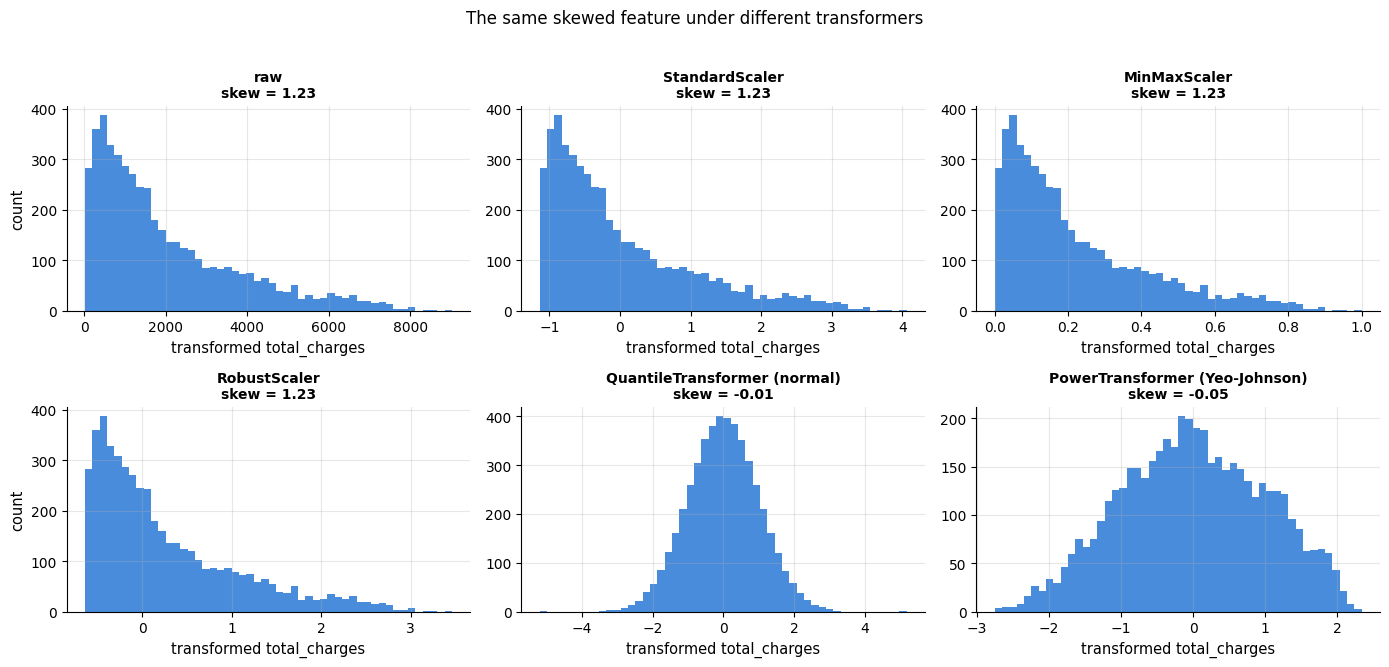

In [18]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler, QuantileTransformer, PowerTransformer

x = cleaned[["total_charges"]].dropna()     # double brackets: a one-column DataFrame, the 2-D shape scikit-learn expects
transforms = {
    "raw": None,                                   # None = leave the values as they are
    "StandardScaler": StandardScaler(),            # (x - mean) / std
    "MinMaxScaler": MinMaxScaler(),                # (x - min) / (max - min): values in [0, 1]
    "RobustScaler": RobustScaler(),                # (x - median) / IQR
    # maps each value through the empirical CDF (estimated at 500 quantiles) onto a standard normal distribution
    "QuantileTransformer (normal)": QuantileTransformer(output_distribution="normal", n_quantiles=500, random_state=RANDOM_STATE),
    "PowerTransformer (Yeo-Johnson)": PowerTransformer(),     # method="yeo-johnson" by default; also standardises
}
fig, axes = plt.subplots(2, 3, figsize=(14, 6.5))
for ax, (name, tf) in zip(axes.ravel(), transforms.items()):    # axes.ravel(): the 2 x 3 grid as a flat list of 6 panels
    # fit_transform = fit, then transform the same data; .ravel() flattens (n, 1) to (n,) for the histogram
    values = x.to_numpy().ravel() if tf is None else tf.fit_transform(x).ravel()
    ax.hist(values, bins=50, color=PALETTE[0], alpha=0.85)
    # pandas .skew(): 0 for a symmetric distribution, positive for a long right tail
    ax.set_title(f"{name}\nskew = {pd.Series(values).skew():.2f}", fontsize=10)
    ax.set_xlabel("transformed total_charges")
axes[0, 0].set_ylabel("count")
axes[1, 0].set_ylabel("count")
fig.suptitle("The same skewed feature under different transformers", y=1.02)
plt.tight_layout()
plt.show()

The three linear scalers change the axis labels but not the *shape* of the distribution —
the skew is untouched. Only the non-linear `QuantileTransformer` and `PowerTransformer`
reshape it. Whether reshaping helps depends on the model: a linear model benefits when the
relationship with the target becomes closer to linear (often the case after a log-like
transform of a right-skewed feature); a tree does not care.

The histograms show one column at a time; the *geometry* of two columns together is what a
distance-based model actually sees. Below, `tenure_months` and `total_charges` are plotted
against each other under four transforms, with a fixed pair of points marked. In the raw
units the vertical axis spans thousands and the horizontal one spans tens, so the distance
between any two customers is essentially the difference in `total_charges` alone; after
standardisation both columns contribute; after the quantile transform the cloud is
re-shaped into a Gaussian blob and the relative distances change again.

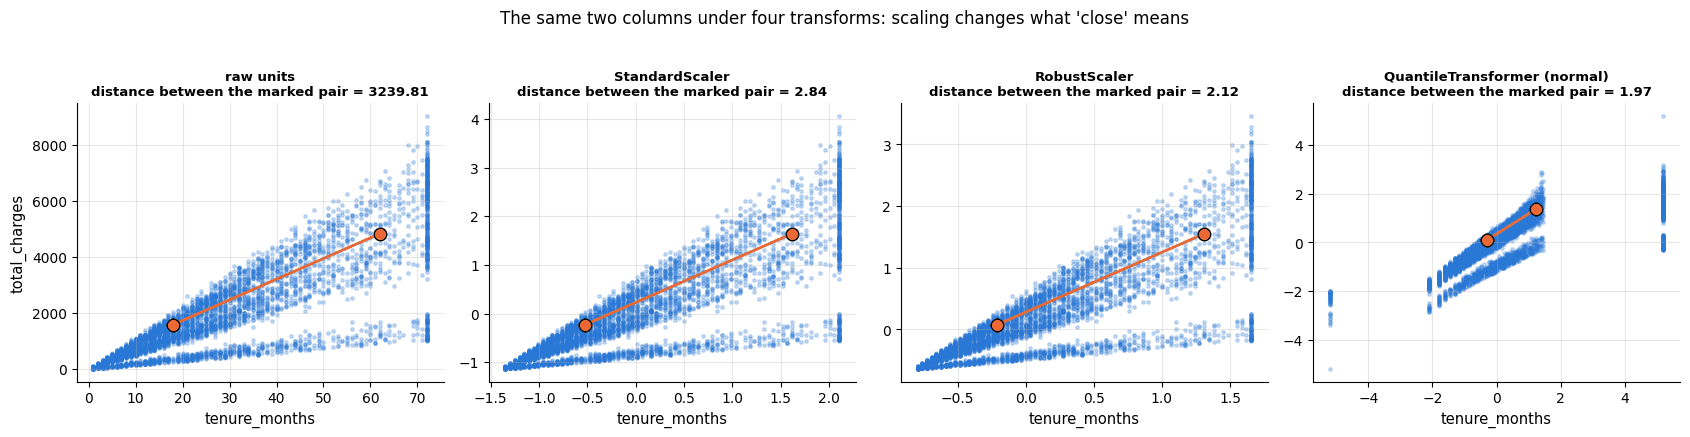

In [19]:
pair = cleaned[["tenure_months", "total_charges"]].dropna()
# the row positions of two fixed customers (positions 5 and 900); .get_loc turns an index label into a position
marked = [pair.index.get_loc(i) for i in pair.index[[5, 900]]]
geom = {      # each value is the (n, 2) array after one transform, fitted on both columns together
    "raw units": pair.to_numpy(),
    "StandardScaler": StandardScaler().fit_transform(pair),
    "RobustScaler": RobustScaler().fit_transform(pair),
    "QuantileTransformer (normal)": QuantileTransformer(output_distribution="normal", n_quantiles=500,
                                                        random_state=RANDOM_STATE).fit_transform(pair),
}
fig, axes = plt.subplots(1, 4, figsize=(17, 4.2))
for ax, (name, Z) in zip(axes, geom.items()):
    ax.scatter(Z[:, 0], Z[:, 1], s=6, alpha=0.25, color=PALETTE[0])
    # a line joining the two marked points; ms = marker size, mec = marker edge colour
    ax.plot(Z[marked, 0], Z[marked, 1], marker="o", ms=9, color=PALETTE[1], lw=2, mec="black")
    d = np.linalg.norm(Z[marked[0]] - Z[marked[1]])      # Euclidean distance between the marked pair
    ax.set_title(f"{name}\ndistance between the marked pair = {d:.2f}", fontsize=9.5)
    ax.set_xlabel("tenure_months")
axes[0].set_ylabel("total_charges")
fig.suptitle("The same two columns under four transforms: scaling changes what 'close' means", y=1.03)
plt.tight_layout()
plt.show()

The last question a power transform is meant to answer is whether the column is now
*approximately normal*, and the honest way to check that is a **Q–Q plot**: sort the values,
plot them against the quantiles a Gaussian would have produced, and look for a straight line.
The raw column bends away from the line at both ends; Yeo–Johnson straightens most of it, and
the rank-based quantile transform straightens it by construction (at the cost of destroying
the original spacing between values).

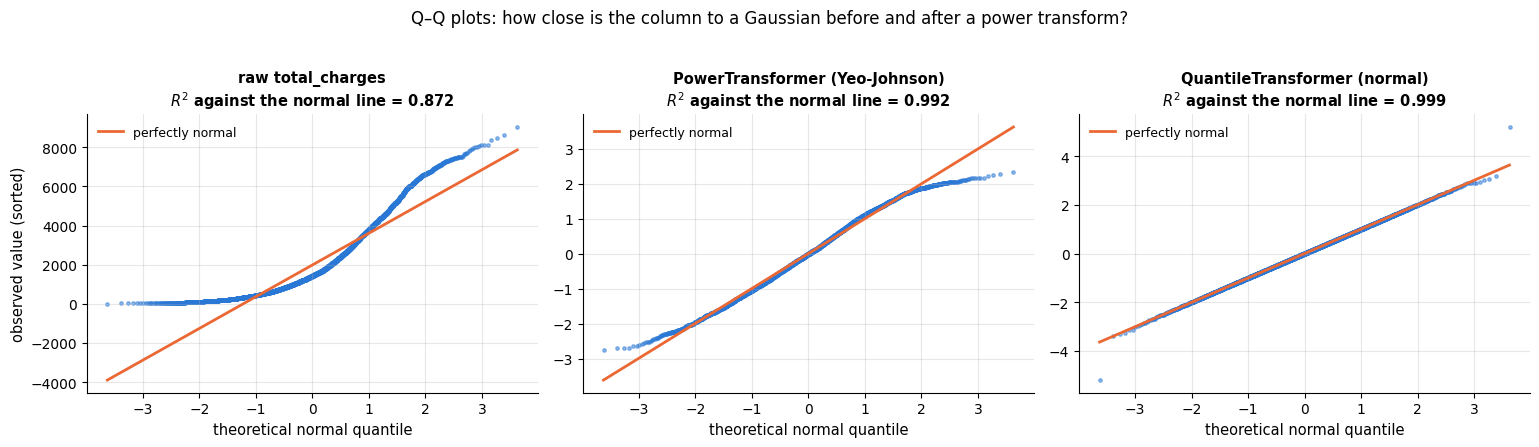

In [20]:
from scipy import stats      # SciPy's statistics module: distributions, tests and probability plots

qq_data = {
    "raw total_charges": x.to_numpy().ravel(),
    "PowerTransformer (Yeo-Johnson)": PowerTransformer().fit_transform(x).ravel(),
    "QuantileTransformer (normal)": QuantileTransformer(output_distribution="normal", n_quantiles=500,
                                                        random_state=RANDOM_STATE).fit_transform(x).ravel(),
}
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
for ax, (name, values) in zip(axes, qq_data.items()):
    # stats.probplot sorts the values (osr) and pairs them with the matching normal quantiles (osm); it also fits
    # a straight line through the points and returns its slope, intercept and correlation r (nested tuple unpacking)
    (osm, osr), (slope, intercept, r) = stats.probplot(values, dist="norm")
    ax.scatter(osm, osr, s=6, color=PALETTE[0], alpha=0.5)
    ax.plot(osm, slope * osm + intercept, color=PALETTE[1], lw=2, label="perfectly normal")
    ax.set_title(f"{name}\n$R^2$ against the normal line = {r ** 2:.3f}", fontsize=10.5)   # R^2 = 1: perfectly straight
    ax.set_xlabel("theoretical normal quantile")
    ax.legend(loc="upper left", fontsize=9)
axes[0].set_ylabel("observed value (sorted)")
fig.suptitle("Q–Q plots: how close is the column to a Gaussian before and after a power transform?", y=1.03)
plt.tight_layout()
plt.show()

### 4.2 Does it matter? A quick experiment

Let us measure the effect of scaling on two models applied to the numeric churn features:
$k$-NN, which is distance-based, and logistic regression, which is regularised and fitted by
an iterative solver.

kNN (k=15)           raw      CV ROC-AUC = 0.770 ± 0.015
kNN (k=15)           scaled   CV ROC-AUC = 0.800 ± 0.010
logistic regression  raw      CV ROC-AUC = 0.819 ± 0.008
logistic regression  scaled   CV ROC-AUC = 0.819 ± 0.008


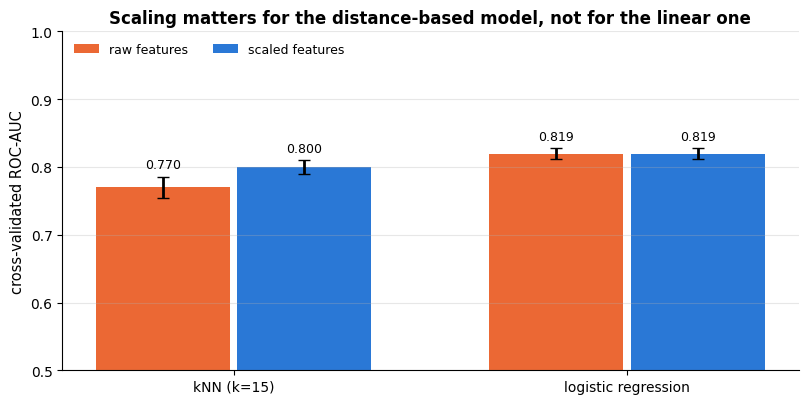

In [21]:
# StratifiedKFold: k-fold splits that keep the class proportions equal in every fold;
# cross_val_score: fits a fresh copy of the model on each training fold and returns one score per validation fold
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier     # predicts the majority class among the k nearest rows
from sklearn.linear_model import LogisticRegression    # a linear classifier for class probabilities (notebook 7)

numeric_cols = ["tenure_months", "monthly_charges", "total_charges", "support_tickets"]
X_num, y = cleaned[numeric_cols], cleaned["churned"]   # features and target (1 = churned)
# 5 folds; shuffle=True shuffles the rows before splitting, random_state makes that reproducible
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scaling_effect = {}
# the two models: k-NN with 15 neighbours, and logistic regression (max_iter=1000 lets its solver run longer)
for model_name, model in [("kNN (k=15)", KNeighborsClassifier(n_neighbors=15)),
                          ("logistic regression", LogisticRegression(max_iter=1000))]:
    for scaled in [False, True]:
        # always impute; add the scaling step only when scaled is True (adding an empty list adds nothing)
        steps = [("impute", SimpleImputer(strategy="median"))] + ([("scale", StandardScaler())] if scaled else [])
        # scoring="roc_auc": area under the ROC curve (0.5 = random ranking, 1 = perfect); auc holds the 5 fold scores
        auc = cross_val_score(Pipeline(steps + [("model", model)]), X_num, y, cv=cv, scoring="roc_auc")
        # the dict key is a (model, variant) tuple; the value is (mean, std) of the fold scores
        scaling_effect[(model_name, "scaled" if scaled else "raw")] = (auc.mean(), auc.std())
        # :20s pads the name to 20 characters so that the columns line up
        print(f"{model_name:20s} {'scaled' if scaled else 'raw   '}   CV ROC-AUC = {auc.mean():.3f} ± {auc.std():.3f}")

fig, ax = plt.subplots(figsize=(9.5, 4.4))
model_names = ["kNN (k=15)", "logistic regression"]
pos = np.arange(len(model_names))          # x positions of the two groups of bars
for k, (variant, colour) in enumerate(zip(["raw", "scaled"], [PALETTE[1], PALETTE[0]])):
    means = [scaling_effect[(m, variant)][0] for m in model_names]
    errs = [scaling_effect[(m, variant)][1] for m in model_names]
    # (k - 0.5) * 0.36 shifts the raw bars left and the scaled bars right of each group centre; 0.34 is the bar width;
    # yerr adds an error bar (here one standard deviation over the folds) with caps of width capsize
    bars = ax.bar(pos + (k - 0.5) * 0.36, means, 0.34, yerr=errs, capsize=4, color=colour,
                  label=f"{variant} features")
    for b, v, e in zip(bars, means, errs):
        # the value, written just above the error bar
        ax.text(b.get_x() + b.get_width() / 2, v + e + 0.012, f"{v:.3f}", ha="center", fontsize=9)
ax.set_xticks(pos, model_names)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("cross-validated ROC-AUC")
ax.set_title("Scaling matters for the distance-based model, not for the linear one", fontsize=12)
ax.legend(loc="upper left", fontsize=9, ncol=2)      # ncol=2: the two legend entries side by side
ax.grid(axis="x", visible=False)
plt.show()

Unscaled $k$-NN is markedly worse: distances are dominated by `total_charges` (values in the
thousands) and the informative `support_tickets` (0–8) barely registers. Logistic regression
is robust here — its quasi-Newton solver reaches the same optimum on this small, well-behaved
problem — but on badly scaled data the solver needs many more iterations (hence the raised
`max_iter`), and the regularisation penalty acts on the unscaled coefficients, which is
rarely what you want. Scale by default: it never hurts a linear model and it is essential
for distance-based ones.

## 5. Encoding categorical variables

### 5.1 One-hot and ordinal encoding

A **nominal** variable (`region`, `payment_method`) has categories with no order. The
standard encoding maps a category with $K$ levels to $K$ binary "dummy" columns:
`Fiber optic` becomes `[0, 1, 0]`. Practical details of `OneHotEncoder`:

- `handle_unknown="ignore"` encodes a category unseen during `fit` as all zeros instead of
  raising. Production data *will* contain new categories; always set this.
- `drop="first"` removes one column per variable. The $K$ dummies sum to 1 and are
  collinear with the intercept, which makes the unregularised normal equations singular
  (the "dummy variable trap", notebook 6). With regularisation — the default in
  `LogisticRegression` and `Ridge`, and irrelevant for trees — this is harmless, and keeping
  all $K$ columns makes coefficients easier to interpret. Drop only for unregularised linear
  models and statistical inference.
- `min_frequency` / `max_categories` lump rare categories into one "infrequent" column.
- `sparse_output=True` (the default) returns a sparse matrix — essential with many
  categories, but incompatible with `set_output(transform="pandas")`.

An **ordinal** variable has ordered levels: `contract` runs `Month-to-month < One year < Two
year`. `OrdinalEncoder` maps the levels to integers in the order *you specify* (the default
alphabetical order is almost never the semantic one): one column instead of $K$, and the
order is available to the model. The cost is an assumption — a linear model treats the step
from level 0 to 1 as equal to the step from 1 to 2. Trees do not, which is why ordinal
encoding is the natural choice for tree models even for nominal variables with many levels
(`HistGradientBoosting*` additionally supports categorical features natively).

In [22]:
from sklearn.preprocessing import OrdinalEncoder      # maps each category to an integer code

# .fit learns the categories of each column (handle_unknown / sparse_output as in section 1.2)
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False).fit(cleaned[["contract", "internet_service"]])
example = pd.DataFrame({"contract": ["One year", "Lifetime"], "internet_service": ["Fiber optic", "DSL"]})
print("one-hot columns:", list(ohe.get_feature_names_out()))     # output column names, "<column>_<category>"
print("encoding of a known row and of a row with the unseen category 'Lifetime':")
print(ohe.transform(example).astype(int))         # .astype(int) prints 0/1 instead of 0./1.

# categories=[[...]]: one list per input column, giving the order of the codes 0, 1, 2;
# handle_unknown="use_encoded_value" with unknown_value=-1 codes an unseen category as -1 instead of raising an error
ord_enc = OrdinalEncoder(categories=[["Month-to-month", "One year", "Two year"]],
                         handle_unknown="use_encoded_value", unknown_value=-1)
codes = ord_enc.fit_transform(cleaned[["contract"]]).ravel().astype(int)    # (n, 1) floats -> (n,) integers
print("\nordinal encoding of contract:")
# pd.crosstab counts each (contract, code) pair: a single non-zero cell per row confirms the mapping
print(pd.crosstab(cleaned["contract"], codes, rownames=["contract"], colnames=["code"]))

one-hot columns: ['contract_Month-to-month', 'contract_One year', 'contract_Two year', 'internet_service_DSL', 'internet_service_Fiber optic', 'internet_service_No']
encoding of a known row and of a row with the unseen category 'Lifetime':
[[0 1 0 0 1 0]
 [0 0 0 1 0 0]]

ordinal encoding of contract:
code               0     1    2
contract                       
Month-to-month  2794     0    0
One year           0  1222    0
Two year           0     0  984


Side by side on four example customers, the three encodings differ in exactly one respect:
how many columns they spend, and what they assume. One-hot spends $K$ columns and assumes
nothing; ordinal spends one column and assumes an order; target encoding spends one column
and assumes that the per-category mean of the target is the useful summary (and, as the next
section shows, has to be computed very carefully). The right panel is the reason this matters
at all: for a column with 400 levels the choice is between 400 columns and 1.

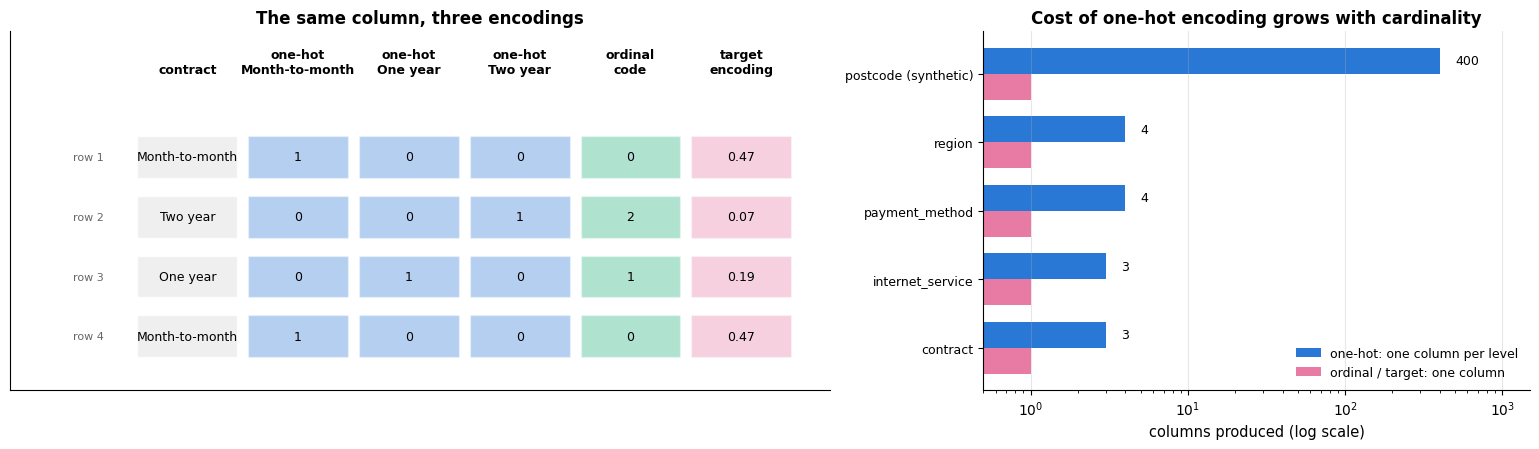

In [23]:
# churn rate per contract type: what an (unsmoothed) target encoding puts in place of each category
contract_rate = cleaned.groupby("contract", observed=True)["churned"].mean()
examples = ["Month-to-month", "Two year", "One year", "Month-to-month"]    # the four example customers
levels = ["Month-to-month", "One year", "Two year"]                         # the order used by the ordinal code
headers = ["contract"] + [f"one-hot\n{lv}" for lv in levels] + ["ordinal\ncode", "target\nencoding"]   # 6 table columns

fig, axes = plt.subplots(1, 2, figsize=(15.5, 4.6), gridspec_kw={"width_ratios": [1.5, 1]})
col_colour = ["0.92"] + [PALETTE[0]] * 3 + [PALETTE[2], PALETTE[4]]      # one colour per table column
# --- left: draw the table cell by cell (column j, row i)
for j, (head, colour) in enumerate(zip(headers, col_colour)):
    axes[0].text(j, len(examples) + 0.35, head, ha="center", va="bottom", fontsize=9, fontweight="bold")
    for i, contract in enumerate(examples):
        # the whole table row for this customer: the label, three 0/1 dummies (int(True) is 1), the ordinal code
        # (levels.index gives the position in the list) and the target encoding; the trailing \ continues the line
        row = [contract] + [f"{int(contract == lv)}" for lv in levels] + \
              [f"{levels.index(contract)}", f"{contract_rate[contract]:.2f}"]
        # a coloured box behind the cell; the first column (j == 0) is drawn more opaque
        axes[0].add_patch(plt.Rectangle((j - 0.45, len(examples) - 1 - i - 0.35), 0.9, 0.7,
                                        facecolor=colour, alpha=0.35 if j else 0.8, edgecolor="white"))
        axes[0].text(j, len(examples) - 1 - i, row[j], ha="center", va="center", fontsize=9)   # this column's entry
for i in range(len(examples)):
    axes[0].text(-0.75, len(examples) - 1 - i, f"row {i + 1}", ha="right", va="center", fontsize=8, color="0.4")
axes[0].set_xlim(-1.6, len(headers) - 0.2)
axes[0].set_ylim(-0.9, len(examples) + 1.1)
axes[0].set_xticks([])
axes[0].set_yticks([])
axes[0].grid(False)
axes[0].set_title("The same column, three encodings")

# --- right: dict comprehension, column name -> number of distinct values (= one-hot columns produced)
cardinality = {c: cleaned[c].nunique() for c in ["contract", "internet_service", "payment_method", "region"]}
cardinality["postcode (synthetic)"] = 400          # a hypothetical high-cardinality column, for comparison
names = list(cardinality)
width = 0.38
# two horizontal bars per variable, shifted up and down by half a bar width
axes[1].barh(np.arange(len(names)) + width / 2, list(cardinality.values()), width, color=PALETTE[0],
             label="one-hot: one column per level")
axes[1].barh(np.arange(len(names)) - width / 2, [1] * len(names), width, color=PALETTE[4],
             label="ordinal / target: one column")
for i, v in enumerate(cardinality.values()):
    axes[1].text(v * 1.25, i + width / 2, f"{v}", va="center", fontsize=9)
axes[1].set_xscale("log")
axes[1].set_xlim(0.5, 1500)
axes[1].set_yticks(range(len(names)), names, fontsize=9)
axes[1].set_xlabel("columns produced (log scale)")
axes[1].set_title("Cost of one-hot encoding grows with cardinality")
axes[1].legend(loc="lower right", fontsize=9)
axes[1].grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

### 5.2 Target encoding and why the naive version leaks

For a variable with hundreds or thousands of levels (postcode, product id, user id), one-hot
encoding produces a huge sparse matrix of nearly-empty columns. **Target encoding**
(Micci-Barreca, 2001) replaces each category $c$ by a statistic of the target within that
category — for a binary target, the smoothed churn rate

$$
\text{enc}(c) \;=\; \frac{n_c\,\bar{y}_c + m\,\bar{y}}{n_c + m},
$$

where $n_c$ is the number of training rows in category $c$, $\bar y_c$ their mean target,
$\bar y$ the global mean and $m$ a smoothing constant that pulls rare categories towards the
global mean. One column, and the model receives directly what it would otherwise have to
learn from $K$ dummies.

The catch is subtle. If we compute $\text{enc}(c)$ on the training rows and then *train the
model on those same rows*, each row's encoded value contains its own label; for a rare
category with $n_c = 1$ the encoded value *is* a shrunk version of the label. The model
learns to trust the column, and that trust is misplaced on new data. This is leakage
*inside* the training set: it does not inflate the validation score, it *hurts* it, because
the model over-weights a noisy feature. The fix, built into
`sklearn.preprocessing.TargetEncoder`, is **cross fitting**: split the training data into
folds and compute each row's encoding from the *other* folds; at `transform` time (test
data) the encoding uses all training rows. Let us demonstrate with a deliberately useless
feature: a fake postcode with 400 levels, drawn at random and unrelated to churn.

In [24]:
from sklearn.base import BaseEstimator, TransformerMixin   # base classes for writing your own transformer
from sklearn.preprocessing import TargetEncoder            # target encoding with built-in cross fitting
from sklearn.model_selection import cross_validate         # like cross_val_score, but returns a dict of results


class NaiveTargetEncoder(BaseEstimator, TransformerMixin):
    """Per-category target mean computed on the fit data and applied to the same data (leaky).

    A minimal scikit-learn transformer for one categorical column: fit() stores the mean target of each
    category, transform() replaces every category by that mean (unseen categories get the overall mean).
    BaseEstimator supplies get_params/set_params, which cross-validation needs to clone the object;
    TransformerMixin supplies fit_transform(), which calls fit() and then transform() on the SAME rows.
    """

    def fit(self, X, y):
        """Learn the overall mean of y (prior_) and the mean of y per category of X (means_); returns self."""
        # np.asarray(...).ravel() flattens the (n, 1) column, so this works for DataFrames and arrays alike
        keys, target = pd.Series(np.asarray(X).ravel()), pd.Series(np.asarray(y))
        self.prior_ = target.mean()                               # global mean, used for unseen categories
        self.means_ = target.groupby(keys).mean().to_dict()      # {category: mean target in that category}
        return self                                               # returning self allows .fit(...).transform(...)

    def transform(self, X):
        """Replace each category in X by its learned target mean; returns an array of shape (n, 1)."""
        keys = pd.Series(np.asarray(X).ravel())
        # .map(dict) looks each value up in the dict (NaN if absent) and .fillna puts the prior there;
        # [:, None] turns the (n,) result into the (n, 1) column a transformer must return
        return keys.map(self.means_).fillna(self.prior_).to_numpy()[:, None]


# six real columns plus a fake postcode: 400 random codes 10000..10399, stored as strings so they act as categories
X_zip = cleaned[["tenure_months", "monthly_charges", "support_tickets", "contract", "payment_method", "internet_service"]].assign(
    postcode=rng.integers(10_000, 10_400, len(cleaned)).astype(str))     # 400 random levels, pure noise

def evaluate_encoding(postcode_encoder, label):
    """Cross-validate a logistic regression with the postcode column encoded by `postcode_encoder`.

    postcode_encoder   a transformer for the postcode column, or None to leave the column out
    label              text for the printed line
    Prints and returns (mean training ROC-AUC, mean validation ROC-AUC) over the folds of `cv`.
    """
    branches = [
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]),
         ["tenure_months", "monthly_charges", "support_tickets"]),
        ("cat", OneHotEncoder(handle_unknown="ignore"), ["contract", "payment_method", "internet_service"]),
    ]
    if postcode_encoder is not None:
        branches.append(("postcode", postcode_encoder, ["postcode"]))     # a third branch for the postcode alone
    # columns not named in any branch are dropped (ColumnTransformer's default remainder="drop")
    pipe = Pipeline([("prep", ColumnTransformer(branches)), ("model", LogisticRegression(max_iter=1000))])
    # return_train_score=True also scores each fold's own training rows, so the two can be compared;
    # res is a dict of arrays with one entry per fold ("train_score", "test_score", fit times, ...)
    res = cross_validate(pipe, X_zip, y, cv=cv, scoring="roc_auc", return_train_score=True)
    print(f"{label:38s} train AUC {res['train_score'].mean():.3f}   validation AUC {res['test_score'].mean():.3f}")
    return res["train_score"].mean(), res["test_score"].mean()

# the "\n" in the keys are line breaks for the bar labels of the next figure. Fitting the pipeline calls
# TargetEncoder.fit_transform, which cross-fits (5 internal folds); random_state seeds its shuffle
encoding_scores = {
    "no postcode\nfeature": evaluate_encoding(None, "without the postcode feature"),
    "naive target\nencoding (leaky)": evaluate_encoding(NaiveTargetEncoder(), "naive target encoding (leaky)"),
    "TargetEncoder\n(cross-fitted)": evaluate_encoding(TargetEncoder(random_state=RANDOM_STATE), "TargetEncoder (cross-fitted)"),
    "one-hot\n(400 columns)": evaluate_encoding(OneHotEncoder(handle_unknown="ignore"), "one-hot (400 columns)"),
}

without the postcode feature           train AUC 0.847   validation AUC 0.846
naive target encoding (leaky)          train AUC 0.877   validation AUC 0.824
TargetEncoder (cross-fitted)           train AUC 0.851   validation AUC 0.845
one-hot (400 columns)                  train AUC 0.881   validation AUC 0.837


The gap between the two bars is the signature to learn. Adding a *useless* feature should
change nothing; the naive encoder instead lifts the training score and pushes the validation
score down, because the encoded column smuggles each row's own label into that row's
features. The cross-fitted `TargetEncoder` leaves both scores where they were.

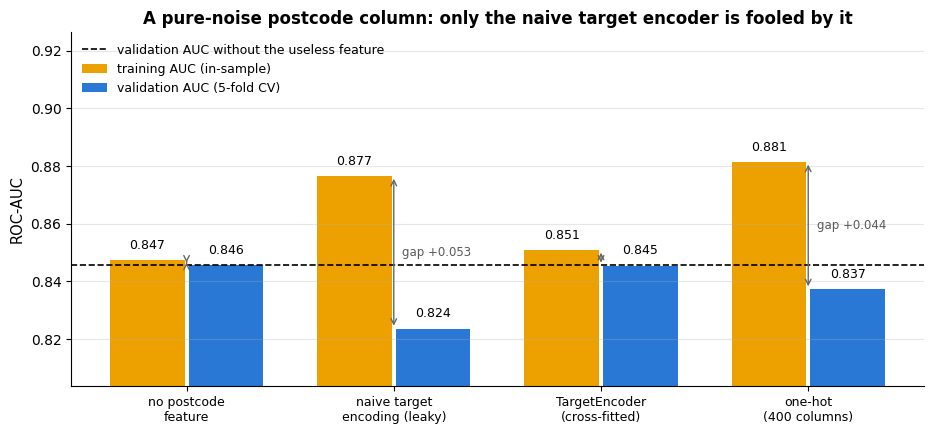

In [25]:
fig, ax = plt.subplots(figsize=(11, 4.6))
labels = list(encoding_scores)
pos = np.arange(len(labels))
train_auc = [encoding_scores[k][0] for k in labels]     # element 0 of each (train, validation) pair
val_auc = [encoding_scores[k][1] for k in labels]
# two bars, 0.36 wide, either side of each group centre
ax.bar(pos - 0.19, train_auc, 0.36, color=PALETTE[3], label="training AUC (in-sample)")
ax.bar(pos + 0.19, val_auc, 0.36, color=PALETTE[0], label="validation AUC (5-fold CV)")
baseline = val_auc[0]                 # validation AUC without the postcode feature
ax.axhline(baseline, color="black", ls="--", lw=1.2, label="validation AUC without the useless feature")
for i, (t, v) in enumerate(zip(train_auc, val_auc)):
    ax.text(i - 0.19, t + 0.004, f"{t:.3f}", ha="center", fontsize=9)
    ax.text(i + 0.19, v + 0.004, f"{v:.3f}", ha="center", fontsize=9)
    # a two-headed arrow spanning the gap between the training and validation scores
    ax.annotate("", xy=(i, t), xytext=(i, v), arrowprops={"arrowstyle": "<->", "lw": 1.0, "color": "0.4"})
    if abs(t - v) > 0.01:                      # label only the gaps that are visible at this scale
        ax.text(i + 0.04, (t + v) / 2, f"gap {t - v:+.3f}", fontsize=8.5, color="0.35", ha="left", va="center")
ax.set_xticks(pos, labels, fontsize=9)
ax.set_ylim(min(val_auc) - 0.02, max(train_auc) + 0.045)
ax.set_ylabel("ROC-AUC")
ax.set_title("A pure-noise postcode column: only the naive target encoder is fooled by it")
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="x", visible=False)
plt.show()

The naive encoder makes the training score go *up* and the validation score go *down* — the
signature of a feature that carries the training labels. The cross-fitted `TargetEncoder`
leaves the useless feature useless (validation AUC unchanged); one-hot encoding of 400
levels also overfits somewhat. With a genuinely informative high-cardinality feature,
cross-fitted target encoding is usually the best of the three.

### 5.3 Other strategies for many levels

- **Frequency encoding** — replace the category by its count or share in the training data;
  cheap, no target needed, informative when rarity itself matters.
- **Hashing** — `FeatureHasher` maps category strings to a fixed number of columns through
  a hash function (Weinberger et al., 2009): no vocabulary to store and unseen categories
  handled for free, at the cost of occasional collisions.
- **Grouping** — domain hierarchies (postcode → district → region), or `min_frequency`.
- **Learned embeddings** — a neural network maps each level to a short dense vector (a deep-learning technique, outside the scope of this course).

Binary variables (`senior_citizen`, `has_partner`, …) are already numbers and need no
encoding; keep them as `0/1` columns.

## 6. Feature engineering

### 6.1 Domain features: encoding what you know

A model can only use structure that is *expressible* in its hypothesis space. Logistic
regression sees a straight line in each feature; if the true effect of tenure on churn is
"very high in the first months, then a sharp drop, then a gentle decline", a linear term
cannot capture the drop — but a flag `new_customer = tenure < 6` can. Feature engineering
builds such columns from domain knowledge (Kuhn & Johnson, 2019; Zheng & Casari, 2018). Let
us look at the tenure effect.

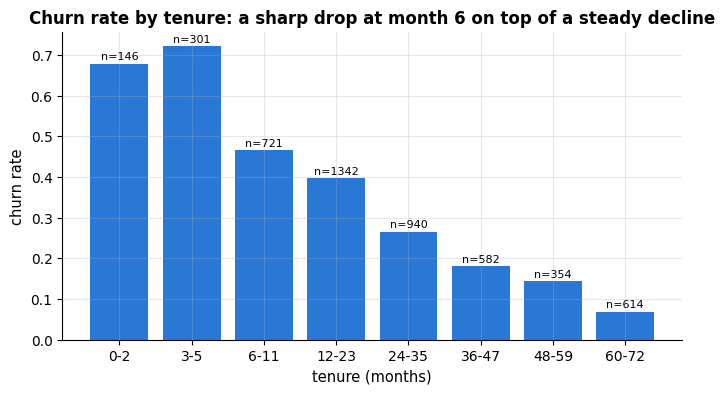

In [26]:
# pd.cut assigns each tenure to an interval of `bins` — (-1, 2], (2, 5], ... (right edge included) — named by `labels`
tenure_bins = pd.cut(cleaned["tenure_months"], bins=[-1, 2, 5, 11, 23, 35, 47, 59, 72],
                     labels=["0-2", "3-5", "6-11", "12-23", "24-35", "36-47", "48-59", "60-72"])
# churn rate ("mean") and number of customers ("size") per bin; observed=True: only bins that occur
rate = cleaned.groupby(tenure_bins, observed=True)["churned"].agg(["mean", "size"])
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(rate.index.astype(str), rate["mean"], color=PALETTE[0])     # the bin labels as plain strings on the x-axis
for i, (m, n) in enumerate(zip(rate["mean"], rate["size"])):
    ax.text(i, m + 0.01, f"n={n}", ha="center", fontsize=8)       # number of customers above each bar
ax.set_xlabel("tenure (months)")
ax.set_ylabel("churn rate")
ax.set_title("Churn rate by tenure: a sharp drop at month 6 on top of a steady decline")
plt.show()

| Family | Examples on the churn data | Notes |
|---|---|---|
| Flags / thresholds | `new_customer = tenure < 6`, `heavy_user = support_tickets >= 3` | encode known non-linearities |
| Ratios and rates | `total_charges / tenure_months`, `support_tickets / tenure_months` | normalise by exposure; guard against division by zero |
| Interactions | `support_tickets * monthly_charges` ("expensive *and* unhappy") | a linear model cannot form products by itself |
| Counts / aggregates | `n_services = tech_support + streaming + (internet != "No")` | summarise related columns |
| Date parts | `signup_month`, `signup_weekday`, `days_since_signup` | seasonality; "days since" relative to a snapshot date |
| Missingness | `total_charges_missing` | informative absence (section 3) |
| Text-derived | length of a complaint, number of exclamation marks (notebook 15) | cheap and often surprisingly strong |

In [27]:
def add_churn_features(df: pd.DataFrame) -> pd.DataFrame:
    """Stateless feature construction for the churn table (safe to apply before splitting).

    Takes the cleaned churn table and returns a copy with seven extra columns: two flags, an interaction,
    a rate, a count, a missing-value indicator and two date features. Nothing is learned from the data.
    """
    snapshot = pd.Timestamp("2024-06-30")                      # date of the data extract
    # .assign(name=values, ...) returns a new frame with these columns added
    return df.assign(
        new_customer=(df["tenure_months"] < 6).astype(int),             # True/False -> 1/0
        tickets_x_charges=df["support_tickets"] * df["monthly_charges"],   # interaction: unhappy AND expensive
        tickets_per_month=df["support_tickets"] / (df["tenure_months"] + 1),   # + 1 avoids dividing by zero
        n_services=df["tech_support"] + df["streaming"] + (df["internet_service"] != "No").astype(int),
        total_charges_missing=df["total_charges"].isna().astype(int),    # missing-value indicator
        signup_month=df["signup_date"].dt.month,                         # .dt.month: 1..12
        days_since_signup=(snapshot - df["signup_date"]).dt.days,
    )

engineered = add_churn_features(cleaned)
engineered[["tenure_months", "new_customer", "support_tickets", "monthly_charges", "tickets_x_charges",
            "tickets_per_month", "n_services", "total_charges_missing", "signup_month", "days_since_signup"]].head()

,tenure_months,new_customer,support_tickets,monthly_charges,tickets_x_charges,tickets_per_month,n_services,total_charges_missing,signup_month,days_since_signup
0,17,0,0,52.96,0.00,0.000000,1,0,1,521
1,6,0,1,92.90,92.90,0.142857,2,1,12,198
2,8,0,2,84.57,169.14,0.222222,1,0,11,241
3,72,0,0,56.87,0.00,0.000000,1,0,7,2164
4,6,0,0,57.42,0.00,0.000000,1,0,12,198


The function is *stateless* — it uses no statistic estimated from the data (the snapshot
date is a property of the extract, not of the training rows) — so it can be applied before
the split without leaking. A feature such as "churn rate of customers in the same region"
would be stateful and would have to live inside the pipeline: it is target encoding in
disguise.

### 6.2 Polynomial, interaction and binned features

Instead of choosing interactions by hand, `PolynomialFeatures(degree=2)` generates *all*
squares and pairwise products (`interaction_only=True`: products only) — $d$ features become
$d(d+3)/2$, fine for a handful of columns and explosive for hundreds; use it with
regularisation (notebook 6). `KBinsDiscretizer` cuts a numeric feature into bins (equal
width, equal frequency or $k$-means) and one-hot encodes the bin: a piecewise-constant
representation that lets a linear model fit any shape, at the cost of losing the order
within a bin. `SplineTransformer` (notebook 6, section 6) is usually the better tool for
smooth non-linearities.

In [28]:
from sklearn.preprocessing import PolynomialFeatures, KBinsDiscretizer

two_cols = cleaned[["tenure_months", "support_tickets"]].iloc[:3]     # the first three rows of two columns
# degree=2: the columns, their squares and their pairwise product (5 columns for 2 inputs);
# include_bias=False leaves out the constant column of ones
poly = PolynomialFeatures(degree=2, include_bias=False).set_output(transform="pandas").fit(two_cols)
print("degree-2 polynomial expansion of two features:")
print(poly.transform(two_cols))
# n_bins=4 bins; strategy="quantile" puts the edges at quantiles, so each bin holds about the same number of rows;
# encode="onehot-dense" outputs one 0/1 column per bin; quantile_method is the np.percentile method for the edges
binner = KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile",
                          quantile_method="averaged_inverted_cdf").set_output(transform="pandas")
# bin_edges_ holds one array of edges per input column; [0] is the only column here
print("\nquantile bins of tenure (edges):", binner.fit(cleaned[["tenure_months"]]).bin_edges_[0].round(1))
print(binner.transform(cleaned[["tenure_months"]].iloc[:3]).astype(int))

degree-2 polynomial expansion of two features:
   tenure_months  ...  support_tickets^2
0           17.0  ...                0.0
1            6.0  ...                1.0
2            8.0  ...                4.0

[3 rows x 5 columns]

quantile bins of tenure (edges): [ 0. 12. 23. 41. 72.]
   tenure_months_0.0  tenure_months_1.0  tenure_months_2.0  tenure_months_3.0
0                  0                  1                  0                  0
1                  1                  0                  0                  0
2                  1                  0                  0                  0


What binning buys is best seen against the empirical churn rate. The grey points are the
observed churn rate in narrow slices of tenure — the shape a model should reproduce. A
logistic regression on raw `tenure_months` can only draw a monotone S-curve through it and
misses the early-life spike completely; the same model on eight one-hot tenure bins is free
to draw a step function and tracks the data. The price is the loss of resolution *inside* a
bin, visible as the flat tops.

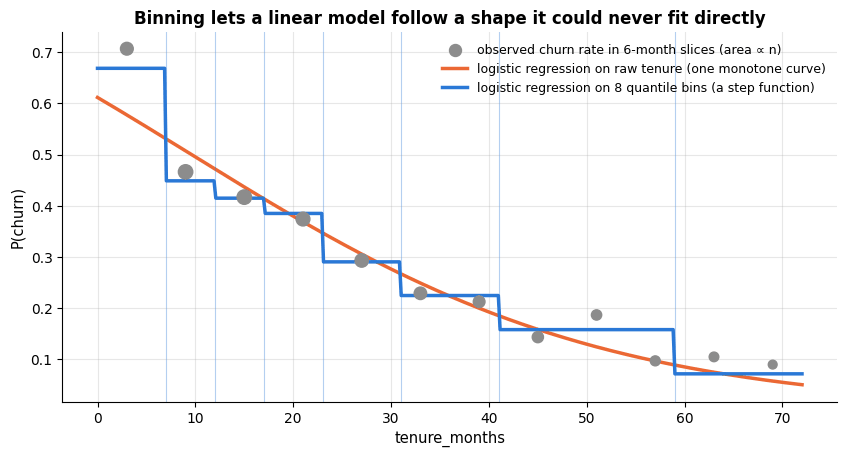

In [29]:
tenure = cleaned[["tenure_months"]]        # a one-column DataFrame, the 2-D input the models need
# 6-month slices [0, 6), [6, 12), ...; right=False includes the left edge and excludes the right one
slices = pd.cut(cleaned["tenure_months"], bins=np.arange(0, 78, 6), right=False)
empirical = cleaned.groupby(slices, observed=True)["churned"].agg(["mean", "size"])
centres = np.array([iv.left + 3 for iv in empirical.index])     # the index holds Intervals; .left = lower edge

# the same logistic regression twice: on standardised raw tenure, and on 8 one-hot quantile bins of tenure
raw_fit = Pipeline([("scale", StandardScaler()), ("lr", LogisticRegression())]).fit(tenure, y)
bin_fit = Pipeline([("bin", KBinsDiscretizer(n_bins=8, encode="onehot-dense", strategy="quantile",
                                             quantile_method="averaged_inverted_cdf")),
                    ("lr", LogisticRegression(max_iter=1000))]).fit(tenure, y)
grid = pd.DataFrame({"tenure_months": np.linspace(0, 72, 400)})    # 400 tenure values at which to draw the curves

fig, ax = plt.subplots(figsize=(10, 4.8))
# s is the marker area (in points squared); here it grows with the number of customers in the slice
ax.scatter(centres, empirical["mean"], s=np.sqrt(empirical["size"]) * 4, color="0.55", zorder=3,
           label="observed churn rate in 6-month slices (area ∝ n)")
# predict_proba returns one column per class, shape (400, 2); [:, 1] is P(churn)
ax.plot(grid, raw_fit.predict_proba(grid)[:, 1], color=PALETTE[1], lw=2.5,
        label="logistic regression on raw tenure (one monotone curve)")
ax.plot(grid, bin_fit.predict_proba(grid)[:, 1], color=PALETTE[0], lw=2.5,
        label="logistic regression on 8 quantile bins (a step function)")
# bin_fit["bin"] is the fitted discretiser; bin_edges_[0] holds all edges of the 8 bins, and [1:-1] drops the
# outermost two, so only the boundaries between neighbouring bins are drawn
for edge in bin_fit["bin"].bin_edges_[0][1:-1]:          # the eight quantile bin edges
    ax.axvline(edge, color=PALETTE[0], lw=0.8, alpha=0.35)
ax.set_xlabel("tenure_months")
ax.set_ylabel("P(churn)")
ax.set_title("Binning lets a linear model follow a shape it could never fit directly")
ax.legend(loc="upper right", fontsize=9)
plt.show()

### 6.3 Transforming the target

A right-skewed *target* (prices, incomes, durations, charges) makes squared-error models
chase a few huge values and produce negative predictions for small ones. Fitting on $\log y$
and exponentiating the predictions is often dramatically better, and
`TransformedTargetRegressor` does the bookkeeping (transform $y$ before `fit`, invert after
`predict`). A regression example inside the churn data: predict `total_charges` from tenure
and monthly charges. Total charges are roughly *monthly charges × months*, so a linear model
in the raw columns is the wrong shape, while a linear model in *logs* — or one that receives
the product as a feature — is exactly right.

In [30]:
from sklearn.compose import TransformedTargetRegressor    # fits on func(y), inverts predictions with inverse_func
from sklearn.linear_model import LinearRegression         # ordinary least squares (notebook 6)
from sklearn.preprocessing import FunctionTransformer     # wraps a plain function as a pipeline step
# r2_score: share of the target's variance explained (1 = perfect); mean_absolute_error: average |prediction - truth|
from sklearn.metrics import r2_score, mean_absolute_error

# customers with both charges known and at least one month billed; .query filters rows with a condition string
billed = cleaned.dropna(subset=["total_charges", "monthly_charges"]).query("tenure_months > 0")
X_bill, y_bill = billed[["tenure_months", "monthly_charges"]], billed["total_charges"]
# with X and y, train_test_split returns four parts: X train, X test, y train, y test
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(X_bill, y_bill, test_size=0.3, random_state=RANDOM_STATE)

# np.log1p(x) = log(1 + x) (defined at 0); np.expm1 is its inverse. feature_names_out="one-to-one" keeps the names
log_features = FunctionTransformer(np.log1p, feature_names_out="one-to-one")
candidates = {
    "linear in raw columns": LinearRegression(),
    # fit on log(1 + y), convert the predictions back with expm1
    "log target only": TransformedTargetRegressor(LinearRegression(), func=np.log1p, inverse_func=np.expm1),
    "log features + log target": TransformedTargetRegressor(Pipeline([("log", log_features), ("lr", LinearRegression())]),
                                                            func=np.log1p, inverse_func=np.expm1),
    # the degree-2 expansion adds tenure², monthly² and the product tenure × monthly
    "raw columns + product feature": Pipeline([("poly", PolynomialFeatures(2, include_bias=False)), ("lr", LinearRegression())]),
}
target_scores = {}
for name, model in candidates.items():
    pred = model.fit(Xb_tr, yb_tr).predict(Xb_te)       # .fit returns the model itself, so .predict can be chained
    target_scores[name] = {"R2": r2_score(yb_te, pred), "MAE": mean_absolute_error(yb_te, pred)}
    print(f"{name:32s} test R² = {target_scores[name]['R2']:.3f}   MAE = {target_scores[name]['MAE']:7.1f}")

linear in raw columns            test R² = 0.898   MAE =   389.5
log target only                  test R² = 0.562   MAE =   608.6
log features + log target        test R² = 0.994   MAE =    76.1
raw columns + product feature    test R² = 0.998   MAE =    51.3


Transforming only the target *hurts* (the model is now linear in $\log y$ but not in the
inputs); transforming both makes the multiplicative structure additive and cuts the error by
a factor of five; and giving the linear model the product `tenure × monthly` is best of all,
because it *is* the data-generating mechanism up to noise.

The first two panels below show *why* a log target is worth considering at all — the raw
bills pile up near zero with a long tail to the right (skew $+1.2$, mean well above the
median), while the log compresses that tail into a mild left skew — and the third shows that
the transform only pays off when the *features* are transformed with it.

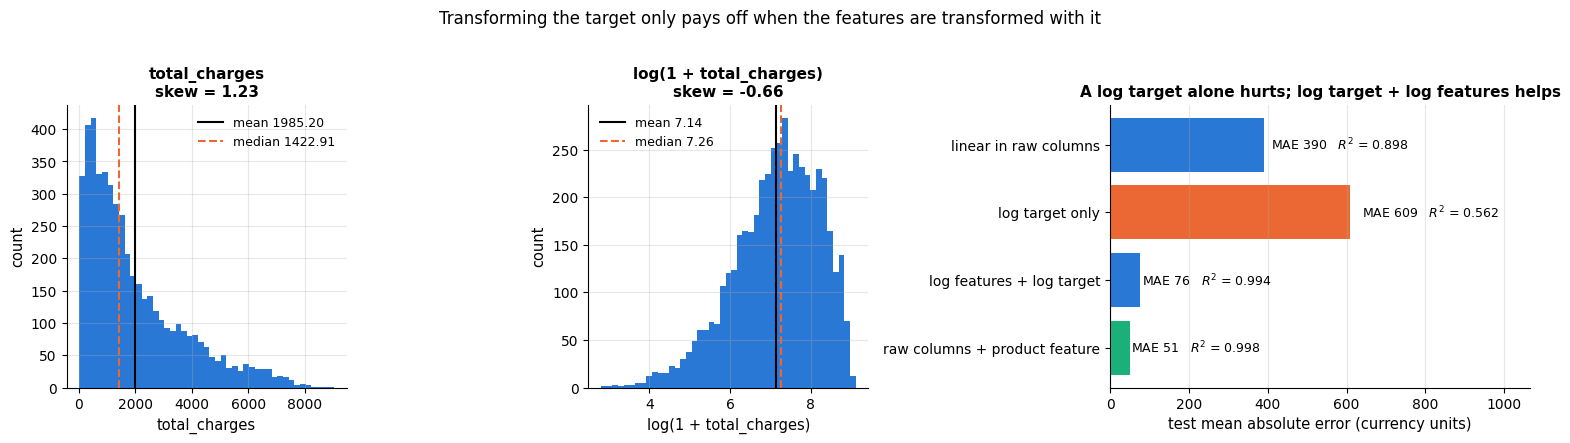

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3), gridspec_kw={"width_ratios": [1, 1, 1.5]})
# zip stops at the shorter list, so this loop fills only the first two panels (raw and log target)
for ax, (values, label) in zip(axes, [(y_bill, "total_charges"), (np.log1p(y_bill), "log(1 + total_charges)")]):
    ax.hist(values, bins=45, color=PALETTE[0])
    ax.axvline(values.mean(), color="black", lw=1.5, label=f"mean {values.mean():.2f}")
    ax.axvline(values.median(), color=PALETTE[1], ls="--", lw=1.5, label=f"median {values.median():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("count")
    ax.set_title(f"{label}\nskew = {values.skew():.2f}", fontsize=11)
    ax.legend(fontsize=9)

names = list(target_scores)
maes = [target_scores[n]["MAE"] for n in names]
# chained conditional expression: orange for the worst MAE, green for the best, blue for the rest
colours = [PALETTE[1] if m == max(maes) else PALETTE[2] if m == min(maes) else PALETTE[0] for m in maes]
axes[2].barh(names, maes, color=colours)
for i, n in enumerate(names):
    axes[2].text(maes[i] * 1.05, i, f"MAE {maes[i]:.0f}   $R^2$ = {target_scores[n]['R2']:.3f}", va="center", fontsize=9)
axes[2].set_xlim(0, max(maes) * 1.75)        # leave room on the right for the labels
axes[2].invert_yaxis()                        # first model at the top
axes[2].set_xlabel("test mean absolute error (currency units)")
axes[2].set_title("A log target alone hurts; log target + log features helps", fontsize=11)
axes[2].grid(axis="y", visible=False)
fig.suptitle("Transforming the target only pays off when the features are transformed with it", y=1.02)
plt.tight_layout()
plt.show()

> **Key idea.** Feature engineering moves knowledge about the problem's structure from the
> model (which would have to learn it from data) into the representation (where it is
> free). Get the shape right first; only then spend capacity on a bigger model.

### 6.4 Can a feature beat a better model?

Gradient boosting (notebook 10) is usually the strongest model for tabular data and can
discover interactions and thresholds by itself. Logistic regression cannot — unless we hand
them over as features. Let us compare, with 5-fold cross-validation, logistic regression on
the original columns, the same model with our engineered features, and gradient boosting on
the original columns.

logistic regression, original features        CV ROC-AUC = 0.847 ± 0.007
logistic regression + engineered features     CV ROC-AUC = 0.854 ± 0.012
gradient boosting, original features          CV ROC-AUC = 0.834 ± 0.012


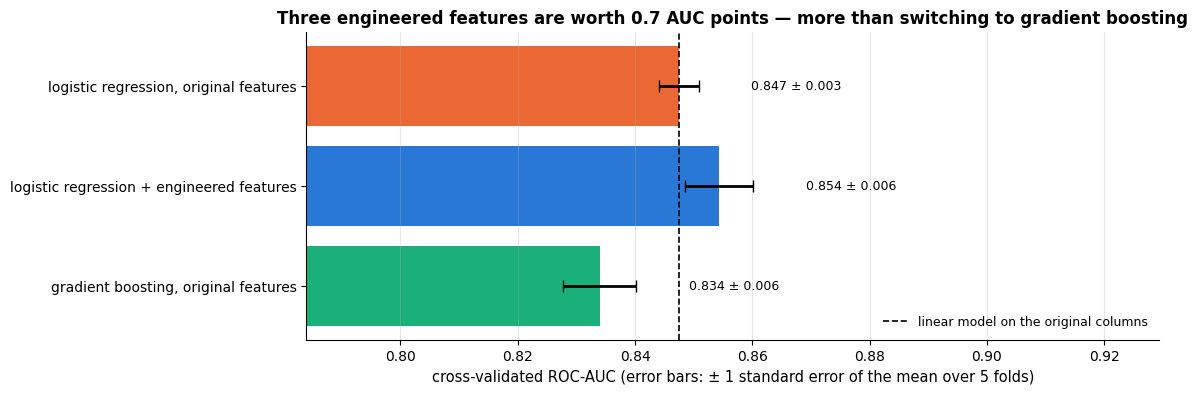

In [32]:
from sklearn.ensemble import HistGradientBoostingClassifier     # gradient-boosted decision trees (notebook 10)

base_numeric = ["tenure_months", "monthly_charges", "total_charges", "support_tickets"]
binary = ["senior_citizen", "has_partner", "tech_support", "streaming"]
categorical = ["contract", "payment_method", "internet_service", "region"]
extra = ["new_customer", "tickets_x_charges", "total_charges_missing"]     # the three engineered features tested here

def make_prep(numeric):
    """Return an unfitted ColumnTransformer that uses the column list `numeric` as its numeric columns.

    Numeric columns are median-imputed and standardised, the `binary` columns pass through unchanged and the
    `categorical` columns are one-hot encoded; every other column is dropped.
    """
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
        ("bin", "passthrough", binary),               # "passthrough": use these columns as they are
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ])

# every column except the target, the id and the raw date; make_prep picks out the columns it needs
X_eng = engineered.drop(columns=["churned", "customer_id", "signup_date"])
experiments = {
    "logistic regression, original features": Pipeline([("prep", make_prep(base_numeric)), ("model", LogisticRegression(max_iter=1000))]),
    "logistic regression + engineered features": Pipeline([("prep", make_prep(base_numeric + extra)), ("model", LogisticRegression(max_iter=1000))]),
    "gradient boosting, original features": Pipeline([("prep", make_prep(base_numeric)), ("model", HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
}
experiment_scores = {}
for name, pipe in experiments.items():
    auc = cross_val_score(pipe, X_eng, y, cv=cv, scoring="roc_auc")     # 5 validation scores, one per fold
    experiment_scores[name] = auc
    print(f"{name:45s} CV ROC-AUC = {auc.mean():.3f} ± {auc.std():.3f}")

fig, ax = plt.subplots(figsize=(11, 4.0))
names = list(experiment_scores)
means = np.array([experiment_scores[n].mean() for n in names])
# standard error of the mean over the folds: sample standard deviation (ddof=1) / sqrt(number of folds)
ses = np.array([experiment_scores[n].std(ddof=1) / np.sqrt(len(experiment_scores[n])) for n in names])
# xerr adds horizontal error bars
bars = ax.barh(names, means, xerr=ses, capsize=4, color=[PALETTE[1], PALETTE[0], PALETTE[2]])
for b, m, s in zip(bars, means, ses):
    # b.get_y() + b.get_height() / 2 is the vertical centre of the horizontal bar b
    ax.text(m + s + 0.009, b.get_y() + b.get_height() / 2, f"{m:.3f} ± {s:.3f}", va="center", fontsize=9)
ax.axvline(means[0], color="black", ls="--", lw=1.2, label="linear model on the original columns")
ax.set_xlim(min(means) - 0.05, max(means) + 0.075)
ax.invert_yaxis()
ax.set_xlabel("cross-validated ROC-AUC (error bars: ± 1 standard error of the mean over 5 folds)")
ax.set_title(f"Three engineered features are worth {100 * (means[1] - means[0]):.1f} AUC points "
             f"— more than switching to gradient boosting", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.grid(axis="y", visible=False)
plt.show()

Three hand-made features lift the linear model above the default gradient-boosting model. This
is not a universal result — with more data or tuning (notebook 12) boosting would catch up,
and it would find *other* structure we did not think of — but it is typical: on small and
medium tabular datasets, careful features plus a simple model are a very strong baseline,
and cheaper to train, explain and maintain.

## 7. Feature selection

More features are not always better: irrelevant columns add noise that a model may fit
(variance), correlated columns make coefficients unstable and hard to interpret, and every
column costs memory, time and maintenance. Guyon & Elisseeff (2003) organise the methods in
three families.

### 7.1 Filter methods: score each feature on its own

A filter ranks features by a statistic computed *without* a model: `VarianceThreshold`
removes near-constant columns; the **ANOVA F-statistic** (`f_classif`), the ratio of
between-class to within-class variance, detects *linear* (mean-shift) relationships with the
class; **mutual information** (`mutual_info_classif`),
$I(X; Y) = \sum P(x, y) \log \frac{P(x,y)}{P(x)P(y)}$ (notebook 2), estimated with a
nearest-neighbour method, detects *any* dependence at the cost of noisier estimates. Filters
are fast and model-agnostic but blind to redundancy (two copies of a feature score
identically) and to interactions (two features useless alone but decisive together).

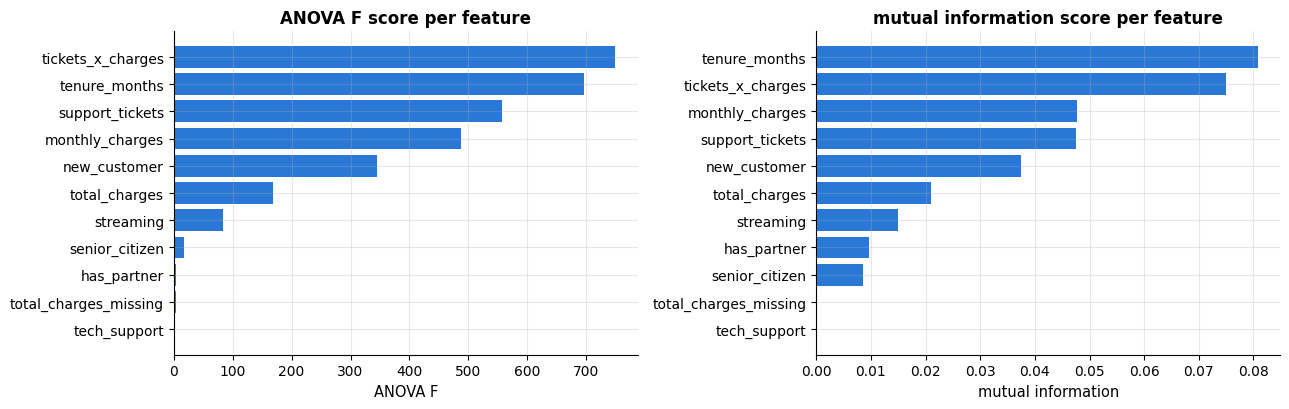

In [33]:
# f_classif: the ANOVA F-statistic of each feature against the class; mutual_info_classif: estimated mutual information
from sklearn.feature_selection import f_classif, mutual_info_classif

# fillna with a Series of medians fills each column's gaps with that column's median
X_filt = X_eng[base_numeric + binary + extra].fillna(X_eng[base_numeric + extra].median(numeric_only=True))
f_scores, _ = f_classif(X_filt, y)          # returns (F-statistics, p-values); _ discards the p-values
# random_state seeds the small random noise the estimator adds to continuous columns
mi_scores = mutual_info_classif(X_filt, y, random_state=RANDOM_STATE)
# one row per feature, one column per statistic
scores = pd.DataFrame({"ANOVA F": f_scores, "mutual information": mi_scores}, index=X_filt.columns)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col in zip(axes, scores.columns):
    s = scores[col].sort_values()          # ascending, so the largest score ends up at the top of the barh chart
    ax.barh(s.index, s.values, color=PALETTE[0])
    ax.set_title(f"{col} score per feature")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()

(The scores are computed on the whole table here for illustration; inside a pipeline
`SelectKBest(f_classif, k=...)` recomputes them on each training fold.) Both statistics
agree on the strongest signals — tenure, the tickets × charges interaction, tickets, monthly
charges, the new-customer flag — and both rate `tech_support` at essentially zero. That last
verdict is wrong, and instructively so: customers with tech support churn *less*, other
things being equal (the model in notebook 7 gives it a clearly negative coefficient), but
they also pay more and file fewer tickets, and marginally the effects cancel. A filter judges
each feature in isolation and cannot see an effect that only appears *conditional* on other
features; wrappers and embedded methods can.

### 7.2 Wrapper methods: search with the model in the loop

A wrapper evaluates *subsets* of features by fitting the actual model. **Recursive feature
elimination** (`RFE`) fits the model, removes the weakest feature(s) by coefficient or
importance, and repeats; `RFECV` chooses the number of features by cross-validation.
**Sequential feature selection** (`SequentialFeatureSelector`) adds (forward) or removes
(backward) one feature at a time, keeping the change that most improves a cross-validated
score — greedy and expensive ($O(d^2)$ model fits), but it directly optimises what you care
about.

In [34]:
# RFE: recursive feature elimination; SequentialFeatureSelector: greedy forward or backward selection with CV
from sklearn.feature_selection import RFE, SequentialFeatureSelector

prep_all = make_prep(base_numeric + extra).set_output(transform="pandas")
X_prep = prep_all.fit_transform(X_eng)          # illustration only: in a pipeline this happens per fold
# the output columns are named "<branch>__<column>" (e.g. "num__tenure_months"); split("__", 1)[1] keeps the column part
feature_names = [n.split("__", 1)[1] for n in X_prep.columns]

sub = rng.choice(len(X_prep), 1500, replace=False)        # wrappers cost O(d^2) fits: run them on a subsample
X_sub, y_sub = X_prep.iloc[sub], y.iloc[sub]             # .iloc selects those rows by position

# RFE fits the model, drops the feature with the smallest |coefficient| and refits, until 6 features are left
rfe = RFE(LogisticRegression(max_iter=1000), n_features_to_select=6).fit(X_prep, y)
# forward selection: start with no features and repeatedly add the one that most improves the 3-fold CV ROC-AUC
sfs = SequentialFeatureSelector(LogisticRegression(max_iter=1000), n_features_to_select=6,
                                direction="forward", scoring="roc_auc", cv=3).fit(X_sub, y_sub)
# number of fits: step k (k = 0..5) tries each of the X_prep.shape[1] - k remaining features, with 3 CV folds each
print(f"{X_prep.shape[1]} candidate columns; forward selection fits the model "
      f"{sum(X_prep.shape[1] - k for k in range(6)) * 3} times, which is why it runs on {len(sub)} rows")
# rfe.support_ and sfs.get_support() are True/False masks over the columns (True = kept);
# the list comprehensions keep the names whose mask entry is True
print("RFE keeps:               ", [f for f, keep in zip(feature_names, rfe.support_) if keep])
print("forward selection keeps: ", [f for f, keep in zip(feature_names, sfs.get_support()) if keep])

25 candidate columns; forward selection fits the model 405 times, which is why it runs on 1500 rows
RFE keeps:                ['tenure_months', 'monthly_charges', 'tickets_x_charges', 'contract_Month-to-month', 'contract_One year', 'contract_Two year']
forward selection keeps:  ['tenure_months', 'monthly_charges', 'tickets_x_charges', 'tech_support', 'contract_Month-to-month', 'contract_Two year']


### 7.3 Embedded methods: selection as a by-product of fitting

Some models select features while they learn. The **L1 (lasso) penalty** (notebook 6,
section 7) drives coefficients of unhelpful features to exactly zero; `SelectFromModel`
around an L1-penalised model turns this into a transformer. **Tree ensembles** report
`feature_importances_`, the total impurity reduction attributed to each feature —
convenient, but biased towards features with many possible split points (continuous or
high-cardinality ones) and unreliable when features are correlated (Strobl et al., 2007).
Prefer *permutation importance* (notebook 17) for ranking, and treat impurity importances
as a rough guide only.

In [35]:
# {'C':>7s} right-aligns the text "C" in a field of 7 characters, so it sits above the C column
print(f"{'C':>7s}  non-zero coefficients (L1-penalised logistic regression on the standardised matrix)")
for C in [0.003, 0.01, 0.03, 0.1, 1.0]:          # C is the inverse penalty strength: small C = strong penalty
    # solver="liblinear" is one of the solvers that supports the L1 penalty
    l1 = LogisticRegression(l1_ratio=1, C=C, solver="liblinear").fit(X_prep, y)   # l1_ratio=1: pure L1 penalty
    # coef_ has shape (1, n_features); keep the names whose coefficient is not (numerically) zero
    kept = [f for f, c in zip(feature_names, l1.coef_.ravel()) if abs(c) > 1e-6]
    # print at most 8 names, then ", ..." if there are more
    print(f"{C:7.3f}  {len(kept):2d}: {', '.join(kept[:8]) + (', ...' if len(kept) > 8 else '')}")

      C  non-zero coefficients (L1-penalised logistic regression on the standardised matrix)
  0.003   4: tenure_months, monthly_charges, new_customer, tickets_x_charges
  0.010   6: tenure_months, monthly_charges, new_customer, tickets_x_charges, contract_One year, contract_Two year
  0.030  14: tenure_months, monthly_charges, total_charges, new_customer, tickets_x_charges, senior_citizen, has_partner, tech_support, ...
  0.100  17: tenure_months, monthly_charges, total_charges, new_customer, tickets_x_charges, total_charges_missing, senior_citizen, has_partner, ...
  1.000  21: tenure_months, monthly_charges, total_charges, support_tickets, new_customer, tickets_x_charges, total_charges_missing, senior_citizen, ...


As the penalty weakens (larger `C`), features enter roughly in order of usefulness — the
same handful first, `tech_support` among the next group (the conditional effect the filters
missed). The path itself is a useful importance summary for linear models.

Each of the three families produces an *ordering* of the features, so they can be compared on
equal terms: take the top $k$ features according to each ordering, cross-validate the same
model on them, and plot the score against $k$. The result is the practical summary of this
whole section.

filter (ANOVA F)       top-3 features: ['tickets_x_charges', 'contract_Month-to-month', 'tenure_months']
wrapper (RFE)          top-3 features: ['contract_Month-to-month', 'tickets_x_charges', 'tenure_months']
embedded (L1 path)     top-3 features: ['tenure_months', 'tickets_x_charges', 'monthly_charges']


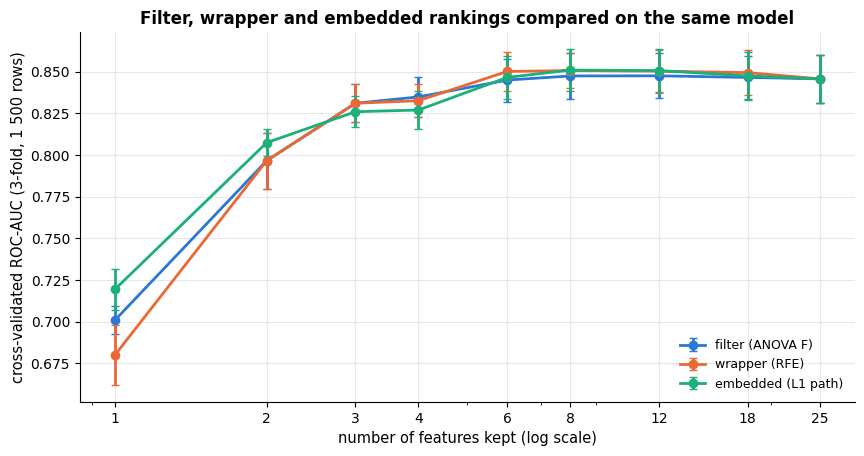

In [36]:
f_all, _ = f_classif(X_prep, y)
filter_order = np.argsort(-f_all)        # argsort of the negated scores: column positions from highest F to lowest
# RFE all the way down to 1 feature: ranking_ is 1 for the last survivor, 2 for the one dropped just before, ...;
# argsort of the ranking lists the columns from most to least useful
wrapper_order = np.argsort(RFE(LogisticRegression(max_iter=1000), n_features_to_select=1)
                          .fit(X_sub, y_sub).ranking_)          # rank 1 = eliminated last = most useful
entry_C = np.full(X_prep.shape[1], np.inf)                      # C at which each coefficient leaves zero
for C in np.logspace(-3, 0.5, 12):       # 12 values of C from 10^-3 to 10^0.5, evenly spaced on a log scale
    coefs = LogisticRegression(l1_ratio=1, C=C, solver="liblinear").fit(X_sub, y_sub).coef_.ravel()
    # record this C for coefficients that are non-zero now and have no entry yet (entry_C still inf)
    entry_C = np.where((np.abs(coefs) > 1e-6) & ~np.isfinite(entry_C), C, entry_C)
embedded_order = np.argsort(entry_C)     # earliest entry first; features that never entered (inf) come last

ks = [1, 2, 3, 4, 6, 8, 12, 18, X_prep.shape[1]]          # numbers of features to keep
curves = {"filter (ANOVA F)": filter_order, "wrapper (RFE)": wrapper_order, "embedded (L1 path)": embedded_order}
fig, ax = plt.subplots(figsize=(10, 4.8))
for (name, order), colour in zip(curves.items(), [PALETTE[0], PALETTE[1], PALETTE[2]]):
    means, ses = [], []
    for k in ks:
        # cross-validate on the top-k columns of this ordering (.iloc[:, positions] selects columns by position)
        s = cross_val_score(LogisticRegression(max_iter=1000), X_sub.iloc[:, order[:k]], y_sub,
                            cv=3, scoring="roc_auc")
        means.append(s.mean())
        ses.append(s.std(ddof=1) / np.sqrt(len(s)))           # standard error over the 3 folds
    ax.errorbar(ks, means, yerr=ses, marker="o", capsize=3, color=colour, label=name)   # a line with error bars
    print(f"{name:22s} top-3 features: {[feature_names[i] for i in order[:3]]}")
ax.set_xscale("log")
ax.set_xticks(ks, [str(k) for k in ks])        # a tick at every k, labelled with plain numbers
ax.set_xlabel("number of features kept (log scale)")
ax.set_ylabel("cross-validated ROC-AUC (3-fold, 1 500 rows)")
ax.set_title("Filter, wrapper and embedded rankings compared on the same model")
ax.legend(loc="lower right", fontsize=9)
plt.show()

All three orderings agree on the first few features and reach the same plateau, which is the
usual outcome on a small, well-behaved feature set: the expensive wrapper earns its cost only
when features interact or are strongly redundant. What the curves *do* show is that about six
of the 20-odd columns carry essentially all of the signal — useful to know before deploying a
model that has to collect all of them in production.

### 7.4 Redundant features

Highly correlated features carry the same information twice. For prediction with a
regularised model this is mostly harmless; for interpretation it is a problem, because the
coefficients of correlated features are unstable — a small change in the data moves weight
from one to the other (notebook 6 quantifies this with the variance inflation factor). A
correlation heatmap makes redundancy visible: `total_charges` is, by construction, nearly the
product of `tenure_months` and `monthly_charges`, and the interaction `tickets_x_charges`
is almost collinear with `support_tickets`.

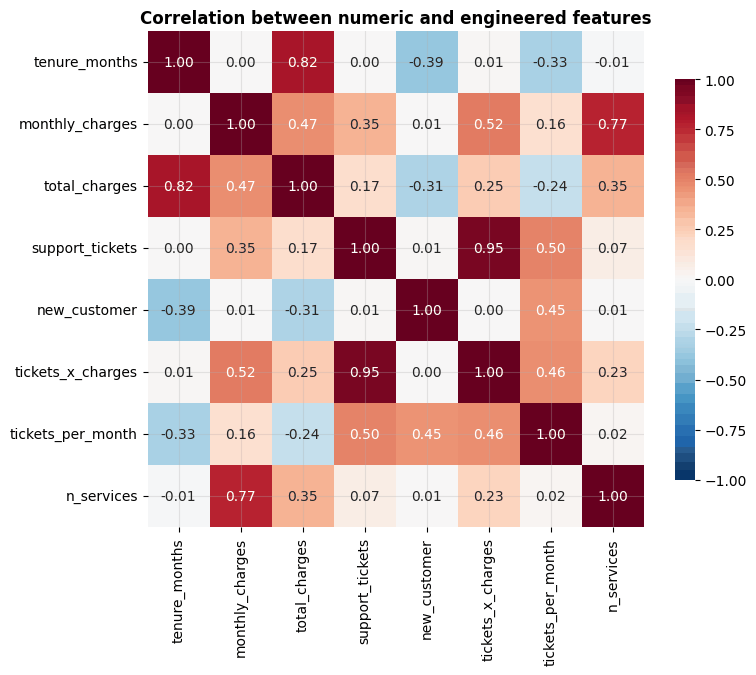

In [37]:
corr_cols = base_numeric + ["new_customer", "tickets_x_charges", "tickets_per_month", "n_services"]
corr = engineered[corr_cols].corr()      # pairwise Pearson correlations: a square table, one row and column per feature
fig, ax = plt.subplots(figsize=(8, 6.5))
# "RdBu_r": red for positive, blue for negative, and center=0 makes zero white; annot/fmt write each value with
# 2 decimals; square=True makes the cells square; shrink=0.8 shortens the colour bar
sns.heatmap(corr, cmap="RdBu_r", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f", square=True, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title("Correlation between numeric and engineered features")
plt.show()

> **Warning.** Every selection method that looks at the target — F-scores, mutual
> information, RFE, lasso — must run *inside* the cross-validated pipeline. Notebook 5,
> section 7.1, showed that selecting on the full data before cross-validating can turn pure
> noise into an apparent 80 % accuracy.

## 8. Imbalanced classes

In the churn data 33 % of customers churn — mildly imbalanced. Fraud detection, rare
diseases and equipment failure routinely have positives below 1 %, and then two things
happen: accuracy becomes meaningless (predicting "never" scores 99 %), and a model trained
to minimise average loss learns to ignore the minority class. Notebook 7 treats the
evaluation side (precision, recall, ROC and precision–recall curves, threshold choice);
here we look at the *training-side* remedies.

### 8.1 Class weights

The simplest remedy reweights the loss: each sample of class $k$ receives weight $w_k$, so
that errors on the minority class cost more. `class_weight="balanced"` sets
$w_k = n / (K\, n_k)$, which makes every class contribute equally regardless of its size.
Almost every scikit-learn classifier supports it; it changes nothing about the data and is
the recommended first step.

In [38]:
# cross_val_predict returns one out-of-fold prediction per row:
# each row is predicted by the fold model that did not train on it
from sklearn.model_selection import cross_val_predict
# precision: share of predicted churners who really churn; recall: share of churners that are caught;
# F1: the harmonic mean of the two; roc_auc_score: ROC-AUC computed from scores or probabilities
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

pipe_lr = Pipeline([("prep", make_prep(base_numeric + extra)), ("model", LogisticRegression(max_iter=1000))])
for weight in [None, "balanced"]:
    # set_params(step__parameter=value) changes a parameter of the named pipeline step ("model" here)
    pipe_lr.set_params(model__class_weight=weight)
    # method="predict_proba" returns class probabilities of shape (n, 2); [:, 1] keeps P(churn)
    proba = cross_val_predict(pipe_lr, X_eng, y, cv=cv, method="predict_proba")[:, 1]
    pred = (proba >= 0.5).astype(int)            # the default decision threshold of 0.5
    # str(weight) turns None into the text "None"; :9s pads it to 9 characters
    print(f"class_weight={str(weight):9s} precision {precision_score(y, pred):.3f}  recall {recall_score(y, pred):.3f}  "
          f"F1 {f1_score(y, pred):.3f}  ROC-AUC {roc_auc_score(y, proba):.3f}  predicted positive rate {pred.mean():.3f}")

class_weight=None      precision 0.736  recall 0.594  F1 0.658  ROC-AUC 0.854  predicted positive rate 0.264
class_weight=balanced  precision 0.620  recall 0.762  F1 0.684  ROC-AUC 0.854  predicted positive rate 0.402


What `class_weight` actually does is easiest to see on a two-dimensional problem where the
decision boundary can be drawn. The left panel is the class balance of the churn data next to
a genuinely rare-event problem; the other two show the same logistic regression on a
roughly 6 % minority class, once with the default weights and once with
`class_weight="balanced"`. The
boundary does not change *shape* — it moves, sweeping more of the space into the minority
class, which is precisely what changing the decision threshold would do.

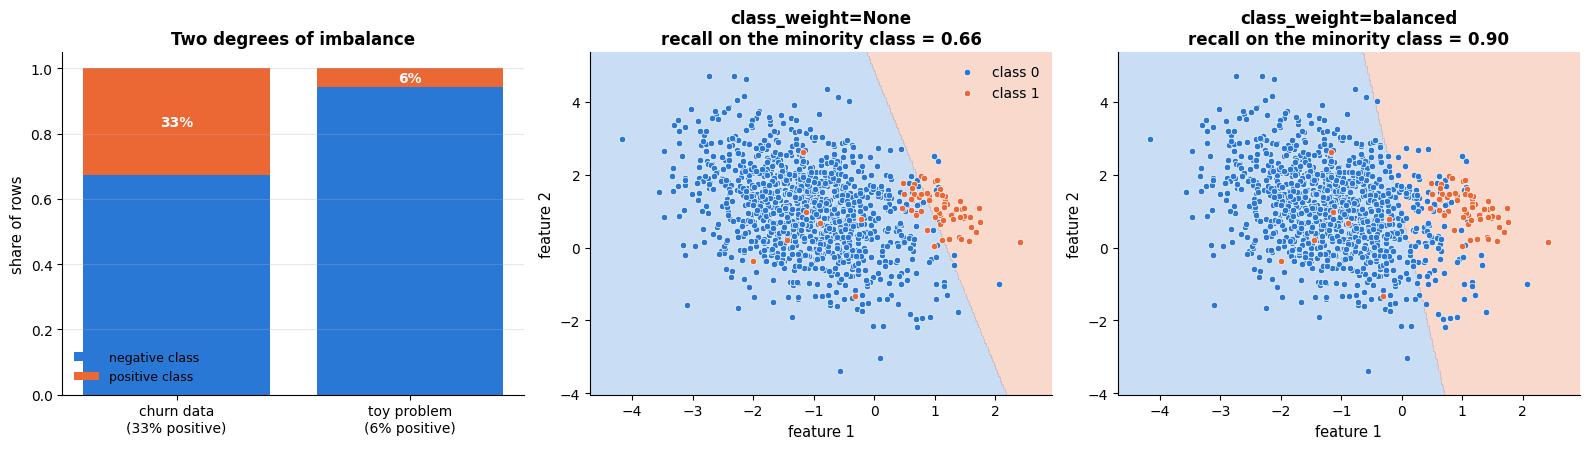

In [39]:
from sklearn.datasets import make_classification       # generates a random synthetic classification problem

# 1200 points with 2 features, both informative, and one cluster per class; weights sets the class proportions,
# class_sep how far apart the classes are, and flip_y=0.01 gives 1 % of the points a random label (label noise)
X_2d, y_2d = make_classification(n_samples=1200, n_features=2, n_redundant=0, n_informative=2,
                                 n_clusters_per_class=1, weights=[0.95, 0.05], class_sep=1.1,
                                 flip_y=0.01, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
# share of positives in each problem; the keys become the bar labels
counts = pd.Series({f"churn data\n({y.mean():.0%} positive)": y.mean(),
                    f"toy problem\n({y_2d.mean():.0%} positive)": y_2d.mean()})
# stacked bars: the negatives from 0 to 1 - p, the positives on top of them (bottom= is where a bar starts)
axes[0].bar(counts.index, 1 - counts.values, color=PALETTE[0], label="negative class")
axes[0].bar(counts.index, counts.values, bottom=1 - counts.values, color=PALETTE[1], label="positive class")
for i, v in enumerate(counts.values):
    # the label sits in the middle of the positive (top) segment, which spans 1 - v to 1
    axes[0].text(i, 1 - v / 2, f"{v:.0%}", ha="center", va="center", color="white", fontweight="bold")
axes[0].set_ylabel("share of rows")
axes[0].set_title("Two degrees of imbalance")
axes[0].legend(loc="lower left", fontsize=9)
axes[0].grid(axis="x", visible=False)

for ax, weight in zip(axes[1:], [None, "balanced"]):
    clf = LogisticRegression(class_weight=weight, max_iter=1000).fit(X_2d, y_2d)
    recall = recall_score(y_2d, clf.predict(X_2d))    # recall of class 1 (the minority), on the training points
    # course_utils helper: shades the region predicted for each class and draws the points on top;
    # legend=(weight is None) shows the legend only in the first of the two panels
    plot_decision_boundary(clf, X_2d, y_2d, ax=ax, legend=(weight is None),
                           title=f"class_weight={weight}\nrecall on the minority class = {recall:.2f}")
plt.tight_layout()
plt.show()

Balanced weights raise recall (more churners caught) at the price of precision (more false
alarms) — here $F_1$ even improves, because the default cut-off of 0.5 is too conservative
for a 33 % problem — while the *ranking* of customers (ROC-AUC) is unchanged: reweighting
acts like a shift of the decision threshold. The threshold is the better place to make that
trade-off explicit, because it can be set from costs (notebook 7, section 5).

### 8.2 Resampling and SMOTE

The alternative is to change the training data: **undersample** the majority class (discards
information), **oversample** the minority by copying rows (invites overfitting to the
copies), or synthesise new minority points. **SMOTE** (Chawla et al., 2002) does the latter
by interpolation: pick a minority point, pick one of its $k$ nearest minority neighbours, and
create a new point at a random position on the segment between them. The idea fits in a few
lines of NumPy; the `imbalanced-learn` package provides production versions (`SMOTE`,
`ADASYN`, `RandomUnderSampler`, …) and a pipeline class that resamples *only the training
folds*.

imbalanced-learn is not installed — the from-scratch SMOTE below illustrates the idea (conda install -c conda-forge imbalanced-learn).


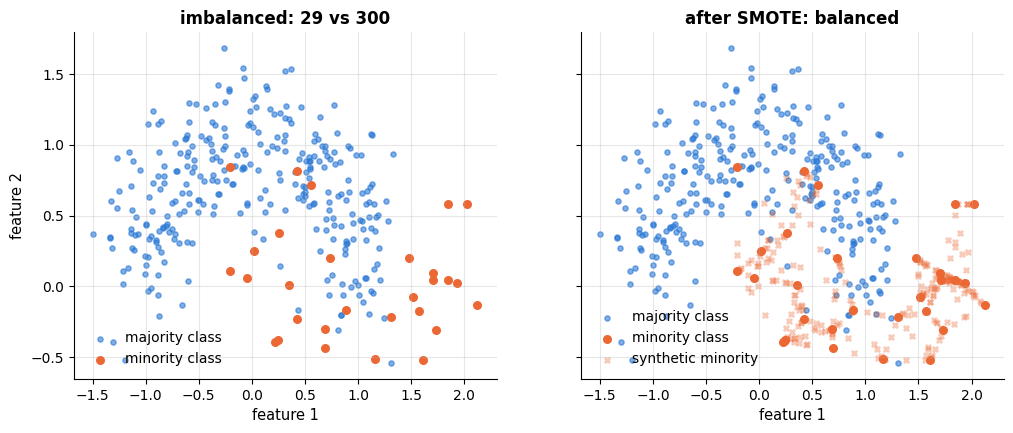

In [40]:
from sklearn.datasets import make_moons                # two interleaving half-circles, a classic 2-D toy problem
from sklearn.neighbors import NearestNeighbors         # finds the nearest rows to a query point (no prediction)

# use the optional imbalanced-learn package if it is installed; ImportError is raised when it is not
try:
    from imblearn.over_sampling import SMOTE  # noqa: F401
    HAS_IMBLEARN = True
    print("imbalanced-learn is installed: imblearn.pipeline.Pipeline accepts SMOTE() as a step (see Exercise 5).")
except ImportError:
    HAS_IMBLEARN = False
    print("imbalanced-learn is not installed — the from-scratch SMOTE below illustrates the idea "
          "(conda install -c conda-forge imbalanced-learn).")

def smote(X_minority, n_new, k=5, rng=rng):
    """Generate n_new synthetic minority samples by interpolating between k-nearest minority neighbours.

    X_minority   array of shape (n_min, d) holding the minority-class points
    n_new        number of synthetic points to create
    k            each new point lies between a random minority point and one of its k nearest minority neighbours
    rng          random generator; the default is the notebook's seeded rng (bound when the function is defined)
    Returns an array of shape (n_new, d).
    """
    neighbours = NearestNeighbors(n_neighbors=k + 1).fit(X_minority)    # k + 1: each point is its own nearest neighbour
    base = rng.integers(0, len(X_minority), n_new)        # n_new random starting points (row indices, repeats allowed)
    nn_idx = neighbours.kneighbors(X_minority[base], return_distance=False)[:, 1:]   # drop the point itself
    # one random neighbour per new point: indexing with two arrays pairs them up, giving nn_idx[r, c[r]] for each row r,
    # where c holds random column numbers 0..k-1
    partner = nn_idx[np.arange(n_new), rng.integers(0, k, n_new)]
    lam = rng.random((n_new, 1))   # one weight in [0, 1) per new point; (n_new, 1) broadcasts over the d columns
    return X_minority[base] + lam * (X_minority[partner] - X_minority[base])    # a random point on each segment

# noise is the standard deviation of the Gaussian noise added to the points
X_moons, y_moons = make_moons(n_samples=600, noise=0.25, random_state=RANDOM_STATE)
keep = (y_moons == 0) | (rng.random(len(y_moons)) < 0.12)         # keep only ~12 % of class 1
X_imb, y_imb = X_moons[keep], y_moons[keep]
# create exactly as many synthetic points as needed to match the majority count
X_syn = smote(X_imb[y_imb == 1], n_new=(y_imb == 0).sum() - (y_imb == 1).sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True, sharey=True)
# left panel without synthetic points (None), right panel with them
for ax, title, synthetic in zip(axes, [f"imbalanced: {(y_imb == 1).sum()} vs {(y_imb == 0).sum()}", "after SMOTE: balanced"], [None, X_syn]):
    ax.scatter(*X_imb[y_imb == 0].T, s=14, color=PALETTE[0], alpha=0.6, label="majority class")   # * unpacks x and y
    ax.scatter(*X_imb[y_imb == 1].T, s=30, color=PALETTE[1], label="minority class")
    if synthetic is not None:
        ax.scatter(*synthetic.T, s=14, color=PALETTE[1], alpha=0.35, marker="x", label="synthetic minority")
    ax.set_title(title)
    ax.set_xlabel("feature 1")
    ax.legend(loc="lower left")
axes[0].set_ylabel("feature 2")
plt.show()

Two warnings apply to every resampling method. **Resample inside the pipeline, training
folds only**: synthetic points derived from validation rows leak, and evaluating on a
resampled validation set measures performance on a population that does not exist.
**Resampling distorts probabilities**: a model trained on 50/50 data predicts churn
probabilities far too high for a 33 % population; if you need calibrated probabilities
(notebook 7, section 6), prefer class weights or, better, an unweighted model plus a tuned
threshold. Empirically, for well-regularised models with a proper metric and a tuned
threshold, class weights and resampling rarely beat each other by much; the metric and the
threshold matter more (He & Garcia, 2009). And stratify every split (`stratify=y`,
`StratifiedKFold`) so that each fold has the same class proportions.

## 9. The complete churn preprocessing pipeline

We now assemble everything into the pipeline that later notebooks reuse. Design decisions:

1. **Cleaning** (`clean_churn`) and **stateless feature construction** (`add_churn_features`)
   happen *before* the split — they learn nothing from the data.
2. The **numeric branch** imputes with the median and standardises; `total_charges` keeps an
   explicit missing indicator (built in `add_churn_features`).
3. **Binary** columns pass through unchanged.
4. The **categorical branch** one-hot encodes with `handle_unknown="ignore"`; all levels are
   kept because every model we use is regularised.
5. Identifiers (`customer_id`), raw dates (`signup_date`, already summarised by tenure) and
   engineered columns that did not improve cross-validated performance
   (`days_since_signup`, `signup_month`, `tickets_per_month`, `n_services`) are **dropped**.

In [41]:
# the column lists that define the inputs of the final pipeline
NUMERIC = ["tenure_months", "monthly_charges", "total_charges", "support_tickets", "tickets_x_charges"]
BINARY = ["senior_citizen", "has_partner", "tech_support", "streaming", "new_customer", "total_charges_missing"]
CATEGORICAL = ["contract", "payment_method", "internet_service", "region"]
TARGET = "churned"


def make_churn_preprocessor() -> ColumnTransformer:
    """Preprocessing for the churn data: apply to the output of add_churn_features(clean_churn(raw)).

    Returns a new, unfitted ColumnTransformer: median imputation and standardisation for NUMERIC, BINARY passed
    through unchanged, one-hot encoding for CATEGORICAL; it outputs a DataFrame with plain column names.
    """
    return ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), NUMERIC),
        ("bin", "passthrough", BINARY),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL),
    ], verbose_feature_names_out=False).set_output(transform="pandas")


churn_features = add_churn_features(load_churn())          # load_churn() == clean_churn(load_churn(raw=True))
X_churn = churn_features[NUMERIC + BINARY + CATEGORICAL]
y_churn = churn_features[TARGET]
# 80 / 20 split; stratify=y_churn keeps the churn rate the same in both parts
X_train, X_test, y_train, y_test = train_test_split(X_churn, y_churn, test_size=0.2, stratify=y_churn, random_state=RANDOM_STATE)

preprocessor = make_churn_preprocessor().fit(X_train)     # learns medians, means, stds and categories from training rows
X_train_prep = preprocessor.transform(X_train)
print(f"{X_train.shape[1]} raw columns -> {X_train_prep.shape[1]} model inputs; train/test = {len(X_train)}/{len(X_test)} rows")
display(X_train_prep.head())
preprocessor      # the HTML diagram shows the structure of the transformer

15 raw columns -> 25 model inputs; train/test = 4000/1000 rows


,tenure_months,monthly_charges,total_charges,support_tickets,tickets_x_charges,senior_citizen,has_partner,tech_support,streaming,new_customer,total_charges_missing,contract_Month-to-month,contract_One year,contract_Two year,payment_method_Bank transfer,payment_method_Credit card,payment_method_Electronic check,payment_method_Mailed check,internet_service_DSL,internet_service_Fiber optic,internet_service_No,region_East,region_North,region_South,region_West
1776,-0.183044,-0.613829,-0.392595,-0.869378,-0.754497,1,0,0,0,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2096,0.253324,0.784173,0.633855,2.559275,2.606149,0,0,0,0,0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3518,-1.152751,0.730069,-0.315148,0.844948,0.898195,0,1,0,0,1,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4827,0.835148,1.028914,1.549207,-0.012215,0.148160,0,0,1,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
4671,-0.910325,-1.790329,-1.041566,-0.869378,-0.754497,0,1,0,0,0,0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('bin', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

Now the models. We cross-validate two very different learners on the training data with
identical preprocessing — the regularised linear model that notebook 7 studies in depth and
the gradient-boosting model of notebook 10 — and report several metrics with their spread
across folds. The test set is *not* touched: it is reserved for the final evaluation in
notebook 7.

In [42]:
from sklearn.dummy import DummyClassifier      # a baseline that ignores the features

candidates = {
    "majority-class baseline": DummyClassifier(strategy="most_frequent"),    # always predicts the most common class
    "logistic regression": LogisticRegression(max_iter=1000),
    "gradient boosting (HGB)": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
rows = []
auc_folds = {}
for name, model in candidates.items():
    pipe = Pipeline([("prep", make_churn_preprocessor()), ("model", model)])    # a fresh preprocessor for each model
    # a list of metrics: res holds one "test_<metric>" array per metric (5 fold scores each) plus "fit_time";
    # "average_precision" summarises the precision-recall curve (notebook 7)
    res = cross_validate(pipe, X_train, y_train, cv=cv, scoring=["roc_auc", "average_precision", "accuracy"])
    auc_folds[name] = res["test_roc_auc"]       # the 5 fold scores, kept for the figure
    # one dict per model, with pre-formatted "mean ± std" strings as values
    rows.append({"model": name,
                 "ROC-AUC": f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
                 "average precision": f"{res['test_average_precision'].mean():.3f} ± {res['test_average_precision'].std():.3f}",
                 "accuracy": f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
                 "fit time (s)": f"{res['fit_time'].mean():.2f}"})
pd.DataFrame(rows).set_index("model")

,ROC-AUC,average precision,accuracy,fit time (s)
model,,,,
majority-class baseline,0.500 ± 0.000,0.326 ± 0.001,0.673 ± 0.000,0.01
logistic regression,0.859 ± 0.015,0.768 ± 0.021,0.802 ± 0.011,0.02
gradient boosting (HGB),0.842 ± 0.013,0.742 ± 0.017,0.791 ± 0.011,0.22


Both models beat the baseline by a wide margin; the engineered features make the simple
linear model at least as good as the default boosting model, and much faster to fit. The
picture puts the three side by side with the uncertainty attached: the error bars are one
standard error of the mean over the five folds, so the gap between the linear model and the
untuned booster is small but larger than the noise, while the gap to the baseline is not
close.

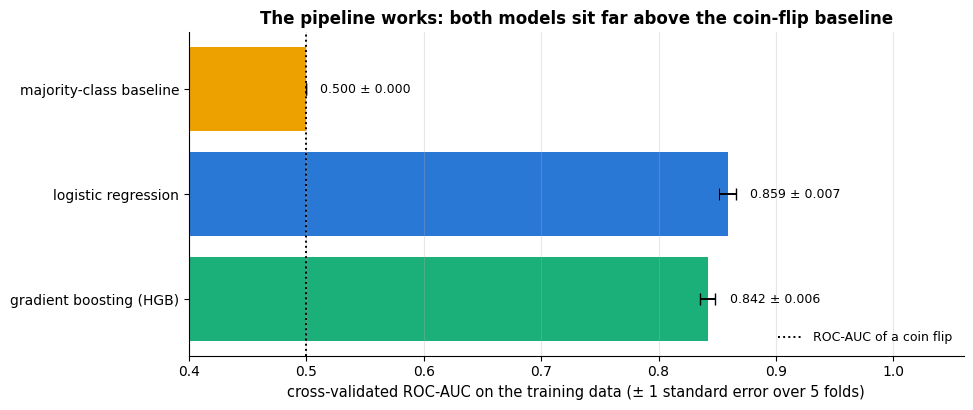

In [43]:
fig, ax = plt.subplots(figsize=(10, 4.2))
names = list(auc_folds)
means = np.array([auc_folds[n].mean() for n in names])
ses = np.array([auc_folds[n].std(ddof=1) / np.sqrt(len(auc_folds[n])) for n in names])    # standard error over the folds
# error_kw sets the style of the error bars
ax.barh(names, means, xerr=ses, color=[PALETTE[3], PALETTE[0], PALETTE[2]],
        error_kw={"ecolor": "black", "capsize": 4, "lw": 1.4})
for i, n in enumerate(names):
    ax.text(means[i] + ses[i] + 0.012, i, f"{means[i]:.3f} ± {ses[i]:.3f}", va="center", fontsize=9)
ax.axvline(0.5, color="black", ls=":", lw=1.4, label="ROC-AUC of a coin flip")
ax.set_xlim(0.4, 1.06)
ax.invert_yaxis()
ax.set_xlabel("cross-validated ROC-AUC on the training data (± 1 standard error over 5 folds)")
ax.set_title("The pipeline works: both models sit far above the coin-flip baseline")
ax.grid(axis="y", visible=False)
ax.legend(loc="lower right", fontsize=9)
plt.show()

Notebook 7 analyses the logistic-regression model in detail (metrics, thresholds,
calibration, odds ratios); notebooks 10 and 12 tune the boosting model.

Finally we record the design so that notebook 18 can turn it into a versioned module. The
column lists and the two functions above are the complete specification; the JSON file
documents it next to the notebook.

In [44]:
Path("artifacts").mkdir(exist_ok=True)      # create the folder; exist_ok=True: no error if it already exists
design = {      # the pipeline specification as plain strings and lists, so it can be saved as JSON
    "dataset": "customer_churn.csv (load_churn)",
    "cleaning": ["drop_duplicates(subset='customer_id')", "region -> strip + title case", "monthly_charges > 200 -> NaN"],
    "engineered_features": ["new_customer = tenure_months < 6", "tickets_x_charges = support_tickets * monthly_charges",
                            "total_charges_missing = total_charges is NaN"],
    "numeric": NUMERIC, "binary": BINARY, "categorical": CATEGORICAL, "target": TARGET,
    "numeric_branch": ["SimpleImputer(strategy='median')", "StandardScaler()"],
    "categorical_branch": ["OneHotEncoder(handle_unknown='ignore')"],
    "split": {"test_size": 0.2, "stratify": True, "random_state": RANDOM_STATE},
}
# "w" opens the file for writing (replacing any old content); `with` closes it again at the end of the block
with open("artifacts/churn_pipeline_design.json", "w") as f:
    json.dump(design, f, indent=2)          # indent=2 writes readable, indented JSON
print("saved artifacts/churn_pipeline_design.json with keys:", list(design))

saved artifacts/churn_pipeline_design.json with keys: ['dataset', 'cleaning', 'engineered_features', 'numeric', 'binary', 'categorical', 'target', 'numeric_branch', 'categorical_branch', 'split']


> **How later notebooks reuse this.** Copy the three column lists and the two functions
> (`add_churn_features`, `make_churn_preprocessor`) — they are short and self-contained — or,
> from notebook 18 on, import them from the `churn_pipeline` module that notebook 18 builds.
> Always apply `add_churn_features` to the cleaned table (`load_churn()`), select
> `NUMERIC + BINARY + CATEGORICAL`, and put `make_churn_preprocessor()` as the first step
> of a `Pipeline`.

## Summary

- Preprocessing follows one contract: **fit on the training data, transform everything
  else**. `Pipeline` and `ColumnTransformer` enforce it inside cross-validation and grid
  search; `set_output(transform="pandas")` keeps column names.
- **Cleaning** (duplicates, category spelling, impossible values, types, consistency checks)
  is stateless and lives in a function applied before the split; everything that estimates a
  statistic lives in the pipeline.
- **Missing data**: the mechanism (MCAR/MAR/MNAR) decides what is safe. Median imputation is
  a fine default; iterative or $k$-NN imputation exploits correlations and removes MAR bias;
  indicators capture informative missingness; tree ensembles handle `NaN` natively.
- **Scaling** is required by distance-based, gradient-based and regularised models and
  irrelevant for trees; `QuantileTransformer` and `PowerTransformer` reshape skewed
  distributions.
- **Encoding**: one-hot for nominal, ordinal for ordered, cross-fitted target encoding or
  hashing for high cardinality; naive target encoding leaks the labels into the features.
- **Feature engineering** moves problem structure into the representation: flags, ratios,
  interactions, date parts, indicators, target transforms. Two good features made a linear
  model beat gradient boosting.
- **Feature selection** (filter, wrapper, embedded) belongs inside the pipeline; impurity
  importances are biased.
- **Imbalance**: class weights first, then threshold tuning (notebook 7); resample only
  training folds and expect distorted probabilities.

| Task | Tool |
|---|---|
| Different treatment per column type | `ColumnTransformer` + `make_column_selector` |
| Readable transformed output | `.set_output(transform="pandas")` |
| Impute | `SimpleImputer(strategy="median"/"most_frequent", add_indicator=True)`, `KNNImputer`, `IterativeImputer` |
| Scale | `StandardScaler` (default), `RobustScaler` (outliers), `PowerTransformer` / `QuantileTransformer` (skew) |
| Encode nominal / ordinal / high-cardinality | `OneHotEncoder(handle_unknown="ignore")` / `OrdinalEncoder(categories=...)` / `TargetEncoder`, `FeatureHasher` |
| Custom stateless features | a plain function, or `FunctionTransformer` inside the pipeline |
| Interactions, bins, smooth non-linearity | `PolynomialFeatures`, `KBinsDiscretizer`, `SplineTransformer` |
| Skewed regression target | `TransformedTargetRegressor(func=np.log1p, inverse_func=np.expm1)` |
| Select features | `SelectKBest`, `RFE`/`RFECV`, `SequentialFeatureSelector`, `SelectFromModel` (L1) |
| Imbalance | `class_weight="balanced"`, `StratifiedKFold`, threshold tuning; `imbalanced-learn` for resampling |

**Next steps:** notebook 6 (linear regression and regularisation) explains *why* scaling
governs conditioning and why regularisation needs standardised features; notebook 7
(logistic regression and classification metrics) evaluates the churn pipeline built here on
the held-out test set; notebook 12 tunes preprocessing choices jointly with model
hyper-parameters; notebook 18 turns the pipeline into a tested, versioned module.

## Exercises

### Exercise 1 — A pipeline for the penguins (easy)
Load `course_utils.load_penguins()` (online: the Palmer penguins; offline: a synthetic
stand-in with the same columns). Build a `ColumnTransformer` that median-imputes and
standardises the four numeric measurements and one-hot encodes `island` and `sex` (which
has missing values — use `SimpleImputer(strategy="most_frequent")` before the encoder), then
cross-validate a `LogisticRegression` that predicts `species`.

<details><summary>Solution sketch</summary>

```py
df = load_penguins().dropna(subset=["species"])
num = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cat = ["island", "sex"]
prep = ColumnTransformer([
    ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num),
    ("cat", make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore")), cat)])
pipe = make_pipeline(prep, LogisticRegression(max_iter=1000))
print(cross_val_score(pipe, df[num + cat], df["species"], cv=5).mean())
```
Accuracy is close to 1: the four measurements separate the species almost perfectly.
</details>

### Exercise 2 — Imputation under MNAR (easy)
Repeat the experiment of section 3.2 with an MNAR mechanism: delete `monthly_charges` with
probability 0.6 when the *value itself* exceeds 90 and 0.05 otherwise. Which imputer
recovers the deleted values best now, and does any of them remove the bias?

<details><summary>Solution sketch</summary>

Set `p_missing = np.where(truth > 90, 0.6, 0.05)`. All imputers are biased downwards; the
iterative imputer is least biased because `total_charges` and the service type still carry
information about the deleted value, but it cannot fully recover it — no method can under
MNAR without modelling the mechanism. A missing indicator lets a downstream model learn that
"missing" means "probably expensive".
</details>

### Exercise 3 — Leaky versus proper target encoding (medium)
Give the fake `postcode` of section 5.2 a *real* signal: draw one hidden effect per postcode
from $\mathcal{N}(0, 0.5)$ and flip labels accordingly (or simply flip 15 % of the labels
within the 50 "worst" postcodes). Compare naive target encoding, `TargetEncoder` and one-hot
encoding by validation AUC. Then vary `TargetEncoder(smooth=...)` over 1, 10 and 100. What
does smoothing do for rare postcodes?

<details><summary>Solution sketch</summary>

With a real signal the cross-fitted encoder now *improves* validation AUC while the naive
encoder still over-trusts the feature (large train/validation gap). Larger `smooth` pulls
rare categories towards the global mean — more bias, less variance; with 400 levels and
about 12 rows each, moderate smoothing (around 10) is usually best.
</details>

### Exercise 4 — Three features of your own (medium)
Engineer three new features for the churn data that are *not* in `add_churn_features` (for
example a `long_contract_and_fiber` interaction, `monthly_charges` relative to the median
bill of the same `internet_service`, or a `senior_and_month_to_month` flag), add them to the
pipeline of section 9, and measure the change in cross-validated ROC-AUC with standard
errors. Are any of the gains larger than one standard error?

<details><summary>Solution sketch</summary>

Compute the relative-bill feature *inside* the pipeline (it uses group medians, i.e.
training statistics) or accept the small leak for a quick test. Most additional features
change AUC by less than one standard error: the two features of section 6.4 already capture
the main non-linearities of this synthetic data. Report non-improvements honestly — that is a
result.
</details>

### Exercise 5 — Class weights versus SMOTE (hard)
Make the churn training data strongly imbalanced by keeping only 10 % of the churners.
Compare (a) plain logistic regression, (b) `class_weight="balanced"`, and (c) logistic
regression on SMOTE-resampled training folds (use the `smote` function of section 8.2 on
the preprocessed matrix, or `imblearn.pipeline.Pipeline` if installed) with `StratifiedKFold`
and the metrics ROC-AUC, average precision and Brier score (notebook 7). Which method gives
the best ranking, and which the best-calibrated probabilities?

<details><summary>Solution sketch</summary>

Ranking metrics (ROC-AUC, average precision) are similar for all three; the Brier score of
(b) and (c) is clearly worse than (a) because their probabilities are shifted upwards.
Implement (c) with a manual CV loop: for each training fold, `prep.fit_transform`, generate
synthetic positives, fit, and evaluate on the untouched validation fold.
</details>

## References and further reading

### Textbooks

- Kuhn, M., & Johnson, K. (2019). *Feature Engineering and Selection: A Practical Approach for Predictive Models*. CRC Press. (free at https://bookdown.org/max/FES/) — The most thorough treatment of this notebook's subject; chapters 5–8 on encoding, engineering numeric predictors and missing data.
- Zheng, A., & Casari, A. (2018). *Feature Engineering for Machine Learning*. O'Reilly. — Practical and compact; good chapters on scaling, categorical variables and text features.
- Little, R. J. A., & Rubin, D. B. (2019). *Statistical Analysis with Missing Data* (3rd ed.). Wiley. — The standard reference on missing-data mechanisms and likelihood-based methods.
- van Buuren, S. (2018). *Flexible Imputation of Missing Data* (2nd ed.). CRC Press. (free at https://stefvanbuuren.name/fimd/) — Multiple imputation by chained equations, the idea behind `IterativeImputer`.
- Müller, A. C., & Guido, S. (2016). *Introduction to Machine Learning with Python*. O'Reilly. — Chapter 4 ("Representing data and engineering features") covers one-hot encoding, binning and interactions at a gentle level.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — Section 3.3 on qualitative predictors and interactions; chapter 6 on selection.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly. — Chapter 2 walks through a complete preprocessing pipeline on a housing dataset.

### Papers

- Rubin, D. B. (1976). Inference and missing data. *Biometrika*, 63(3), 581–592. — Defines MCAR, MAR and MNAR.
- Box, G. E. P., & Cox, D. R. (1964). An analysis of transformations. *Journal of the Royal Statistical Society: Series B*, 26(2), 211–252. — The Box–Cox power transform.
- Yeo, I.-K., & Johnson, R. A. (2000). A new family of power transformations to improve normality or symmetry. *Biometrika*, 87(4), 954–959. — The default method of `PowerTransformer`.
- Micci-Barreca, D. (2001). A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems. *SIGKDD Explorations*, 3(1), 27–32. — Smoothed target encoding.
- Weinberger, K., Dasgupta, A., Langford, J., Smola, A., & Attenberg, J. (2009). Feature hashing for large scale multitask learning. *Proceedings of ICML 2009*, 1113–1120. — The hashing trick.
- Guyon, I., & Elisseeff, A. (2003). An introduction to variable and feature selection. *Journal of Machine Learning Research*, 3, 1157–1182. — The filter / wrapper / embedded taxonomy and its pitfalls.
- Strobl, C., Boulesteix, A.-L., Zeileis, A., & Hothorn, T. (2007). Bias in random forest variable importance measures: illustrations, sources and a solution. *BMC Bioinformatics*, 8, 25. — Why impurity importances favour high-cardinality features.
- Chawla, N. V., Bowyer, K. W., Hall, L. O., & Kegelmeyer, W. P. (2002). SMOTE: synthetic minority over-sampling technique. *Journal of Artificial Intelligence Research*, 16, 321–357.
- He, H., & Garcia, E. A. (2009). Learning from imbalanced data. *IEEE Transactions on Knowledge and Data Engineering*, 21(9), 1263–1284. — A survey of sampling, cost-sensitive and evaluation methods for imbalance.
- Kaufman, S., Rosset, S., Perlich, C., & Stitelman, O. (2012). Leakage in data mining: formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data*, 6(4), 1–21. — Leakage through preprocessing, with real competition examples.
- Stekhoven, D. J., & Bühlmann, P. (2012). MissForest — non-parametric missing value imputation for mixed-type data. *Bioinformatics*, 28(1), 112–118. — Iterative imputation with random forests, a strong non-linear alternative to `IterativeImputer`'s default.

### Documentation and online resources

- scikit-learn user guide, *Preprocessing data* — https://scikit-learn.org/stable/modules/preprocessing.html
- scikit-learn user guide, *Imputation of missing values* — https://scikit-learn.org/stable/modules/impute.html
- scikit-learn user guide, *Pipelines and composite estimators* (`Pipeline`, `ColumnTransformer`, `TransformedTargetRegressor`) — https://scikit-learn.org/stable/modules/compose.html
- scikit-learn user guide, *Feature selection* — https://scikit-learn.org/stable/modules/feature_selection.html
- scikit-learn user guide, *Common pitfalls and recommended practices* — https://scikit-learn.org/stable/common_pitfalls.html
- imbalanced-learn documentation — https://imbalanced-learn.org/stable/ — resamplers and a pipeline that resamples training folds only.
- pandas user guide, *Working with missing data* — https://pandas.pydata.org/docs/user_guide/missing_data.html